# Projeto Airbnb Rio - Ferramenta de Previsão de Preço de Imóvel para pessoas comuns 

### Contexto

No Airbnb, qualquer pessoa que tenha um quarto ou um imóvel de qualquer tipo (apartamento, casa, chalé, pousada, etc.) pode ofertar o seu imóvel para ser alugado por diária.

Você cria o seu perfil de host (pessoa que disponibiliza um imóvel para aluguel por diária) e cria o anúncio do seu imóvel.

Nesse anúncio, o host deve descrever as características do imóvel da forma mais completa possível, de forma a ajudar os locadores/viajantes a escolherem o melhor imóvel para eles (e de forma a tornar o seu anúncio mais atrativo)

Existem dezenas de personalizações possíveis no seu anúncio, desde quantidade mínima de diária, preço, quantidade de quartos, até regras de cancelamento, taxa extra para hóspedes extras, exigência de verificação de identidade do locador, etc.

### Nosso objetivo

Construir um modelo de previsão de preço que permita uma pessoa comum que possui um imóvel possa saber quanto deve cobrar pela diária do seu imóvel.

Ou ainda, para o locador comum, dado o imóvel que ele está buscando, ajudar a saber se aquele imóvel está com preço atrativo (abaixo da média para imóveis com as mesmas características) ou não.

### O que temos disponível, inspirações e créditos

As bases de dados foram retiradas do site kaggle: https://www.kaggle.com/allanbruno/airbnb-rio-de-janeiro

Elas estão disponíveis para download abaixo da aula (se você puxar os dados direto do Kaggle pode ser que encontre resultados diferentes dos meus, afinal as bases de dados podem ter sido atualizadas).

Caso queira uma outra solução, podemos olhar como referência a solução do usuário Allan Bruno do kaggle no Notebook: https://www.kaggle.com/allanbruno/helping-regular-people-price-listings-on-airbnb

Você vai perceber semelhanças entre a solução que vamos desenvolver aqui e a dele, mas também algumas diferenças significativas no processo de construção do projeto.

- As bases de dados são os preços dos imóveis obtidos e suas respectivas características em cada mês.
- Os preços são dados em reais (R$)
- Temos bases de abril de 2018 a maio de 2020, com exceção de junho de 2018 que não possui base de dados

### Expectativas Iniciais

- Acredito que a sazonalidade pode ser um fator importante, visto que meses como dezembro costumam ser bem caros no RJ
- A localização do imóvel deve fazer muita diferença no preço, já que no Rio de Janeiro a localização pode mudar completamente as características do lugar (segurança, beleza natural, pontos turísticos)
- Adicionais/Comodidades podem ter um impacto significativo, visto que temos muitos prédios e casas antigos no Rio de Janeiro

Vamos descobrir o quanto esses fatores impactam e se temos outros fatores não tão intuitivos que são extremamente importantes.

### Importar Bibliotecas e Bases de Dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import numpy as np
import seaborn as sns
import plotly.express as px
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.datasets import make_regression
import shap as sp

c:\Users\Arthur Lindolpho\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Consolidar Base de Dados

In [2]:
meses = {'jan': 1, 'fev': 2, 'mar': 3, 'abr': 4, 'mai': 5, 'jun':6, 'jul': 7, 'ago': 8, 'set': 9, 'out': 10, 'nov':11, 'dez':12}

caminhos = pathlib.Path('dataset')

dfs = []

for arquivo in caminhos.iterdir():
    nome_mes = arquivo.name[:3]
    mes = meses[nome_mes]

    ano = arquivo.name[-8:]
    ano = int(ano.replace('.csv',''))

    df = pd.read_csv(caminhos / arquivo.name)
    df['ano'] = ano
    df['mes'] = mes
    dfs.append(df)

base_airbnb = pd.concat(dfs, ignore_index=False)  
display(base_airbnb)

C:\Users\Arthur Lindolpho\AppData\Local\Temp\ipykernel_16724\4267545800.py:14: DtypeWarning: Columns (62,87) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminhos / arquivo.name)
C:\Users\Arthur Lindolpho\AppData\Local\Temp\ipykernel_16724\4267545800.py:14: DtypeWarning: Columns (61,62,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminhos / arquivo.name)
C:\Users\Arthur Lindolpho\AppData\Local\Temp\ipykernel_16724\4267545800.py:14: DtypeWarning: Columns (61,62,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminhos / arquivo.name)
C:\Users\Arthur Lindolpho\AppData\Local\Temp\ipykernel_16724\4267545800.py:14: DtypeWarning: Columns (87) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminhos / arquivo.name)
C:\Users\Arthur Lindolpho\AppData\Local\Temp\ipykernel_16724\4267545800.py:14: DtypeWarni

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,number_of_reviews_ltm,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,14063,https://www.airbnb.com/rooms/14063,20180414160018,2018-04-14,Living in a Postcard,"Besides the most iconic's view, our apartment ...",NaN,"Besides the most iconic's view, our apartment ...",none,Best and favorite neighborhood of Rio. Perfect...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17878,https://www.airbnb.com/rooms/17878,20180414160018,2018-04-14,Very Nice 2Br - Copacabana - WiFi,Please note that special rates apply for New Y...,- large balcony which looks out on pedestrian ...,Please note that special rates apply for New Y...,none,This is the best spot in Rio. Everything happe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24480,https://www.airbnb.com/rooms/24480,20180414160018,2018-04-14,Nice and cozy near Ipanema Beach,My studio is located in the best of Ipanema. ...,The studio is located at Vinicius de Moraes St...,My studio is located in the best of Ipanema. ...,none,"The beach, the lagoon, Ipanema is a great loca...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25026,https://www.airbnb.com/rooms/25026,20180414160018,2018-04-14,Beautiful Modern Decorated Studio in Copa,"Our apartment is a little gem, everyone loves ...",This newly renovated studio (last renovations ...,"Our apartment is a little gem, everyone loves ...",none,Copacabana is a lively neighborhood and the ap...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31560,https://www.airbnb.com/rooms/31560,20180414160018,2018-04-14,NICE & COZY 1BDR - IPANEMA BEACH,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,none,Die Nachbarschaft von Ipanema ist super lebend...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34324,38844730,https://www.airbnb.com/rooms/38844730,20190923212307,2019-09-24,TRANSAMERICA BARRA DA TIJUCA R IV,"Em estilo contemporâneo, o Transamerica Prime ...",NaN,"Em estilo contemporâneo, o Transamerica Prime ...",none,NaN,...,1.0,1.0,1125.0,1125.0,1.0,1125.0,0.0,15.0,0.0,0.0
34325,38846408,https://www.airbnb.com/rooms/38846408,20190923212307,2019-09-24,Alugo para o Rock in Rio,"Confortável apartamento, 2 quartos , sendo 1 s...",O apartamento estará com mobília completa disp...,"Confortável apartamento, 2 quartos , sendo 1 s...",none,"Muito próximo ao Parque Olímpico, local do eve...",...,2.0,2.0,1125.0,1125.0,2.0,1125.0,0.0,1.0,0.0,0.0
34326,38846703,https://www.airbnb.com/rooms/38846703,20190923212307,2019-09-24,Apt COMPLETO em COPACABANA c/TOTAL SEGURANÇA,Apartamento quarto e sala COMPLETO para curtas...,Espaço ideal para até 5 pessoas. Cama de casal...,Apartamento quarto e sala COMPLETO para curtas...,none,NaN,...,3.0,3.0,1125.0,1125.0,3.0,1125.0,0.0,23.0,6.0,0.0
34327,38847050,https://www.airbnb.com/rooms/38847050,20190923212307,2019-09-24,Cobertura Cinematografica,Cobertura alto nivel,NaN,Cobertura alto nivel,none,NaN,...,1.0,1.0,1125.0,1125.0,1.0,1125.0,0.0,1.0,0.0,0.0


### Se tivermos muitas colunas, já vamos identificar quais colunas podemos excluir

- Como temos muitas colunas, nosso modelo pode ficar muito lento, além disso, com uma análise rápida, podemos ver que muitas colunas não fazem sentido para o nosso modelo de previsão.

- Tipos de colunas que vamos excluir:
    1. IDs, links e informações irrelevantes para o modelo;
    2. Colunas repetidas ou extremamente parecidas, que passam a mesma informação para o modelo;
    3. Colunas de texto livre, no modelo não rodaremos análise de palavras;
    4. Colunas em que todos ou quase todos os valores são iguais;

- Para isso vamos criar um arquivo em excel com os 1000 primeiros registros e fazer uma análise qualitativa

In [3]:
base_airbnb.head(1000).to_csv('Primeiros_registros.xlsx', sep = ';')

### Depois da analise feita, ficamos com as seguintes colunas: 

In [4]:
colunas = ['host_response_time','host_response_rate','host_is_superhost','host_listings_count','latitude','longitude','property_type','room_type','accommodates','bathrooms','bedrooms','beds','bed_type','amenities','price','security_deposit','cleaning_fee','guests_included','extra_people','minimum_nights','maximum_nights','number_of_reviews','review_scores_rating','review_scores_accuracy','review_scores_cleanliness','review_scores_checkin','review_scores_communication','review_scores_location','review_scores_value','instant_bookable','is_business_travel_ready','cancellation_policy','ano','mes']

base_airbnb = base_airbnb.loc[:, colunas]

display(base_airbnb)

,host_response_time,host_response_rate,host_is_superhost,host_listings_count,latitude,longitude,property_type,room_type,accommodates,bathrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,is_business_travel_ready,cancellation_policy,ano,mes
0,NaN,NaN,f,1.0,-22.946854,-43.182737,Apartment,Entire home/apt,4,1.0,...,9.0,9.0,9.0,9.0,9.0,f,f,strict_14_with_grace_period,2018,4
1,within an hour,100%,t,2.0,-22.965919,-43.178962,Condominium,Entire home/apt,5,1.0,...,9.0,10.0,10.0,9.0,9.0,t,f,strict,2018,4
2,within an hour,100%,f,1.0,-22.985698,-43.201935,Apartment,Entire home/apt,2,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,2018,4
3,within an hour,100%,f,3.0,-22.977117,-43.190454,Apartment,Entire home/apt,3,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,2018,4
4,within an hour,100%,t,1.0,-22.983024,-43.214270,Apartment,Entire home/apt,3,1.0,...,10.0,10.0,10.0,10.0,9.0,t,f,strict,2018,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34324,within an hour,93%,f,0.0,-23.003180,-43.342840,Apartment,Entire home/apt,4,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,2019,9
34325,NaN,NaN,f,0.0,-22.966640,-43.393450,Apartment,Entire home/apt,4,2.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,2019,9
34326,within a few hours,74%,f,32.0,-22.962080,-43.175520,Apartment,Entire home/apt,5,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,2019,9
34327,NaN,NaN,f,0.0,-23.003400,-43.341820,Apartment,Entire home/apt,4,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,2019,9


### Tratar Valores Faltando

- Visualizando os dados percebemos que existe uma grande disparidade em dados faltantes, as colunas com mais de 300000 valores NaN foram excluídas da análise.

- Para as outras colunas, como temos muitos dados e essas colunas são valores pequenos comparados ao total de dados, vamos excluir as linhas que contém os dados NaN.

In [5]:
print(base_airbnb.isnull().sum())

host_response_time             401843
host_response_rate             401846
host_is_superhost                 460
host_listings_count               460
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bathrooms                        1724
bedrooms                          850
beds                             2502
bed_type                            0
amenities                           0
price                               0
security_deposit               421280
cleaning_fee                   313506
guests_included                     0
extra_people                        0
minimum_nights                      0
maximum_nights                      0
number_of_reviews                   0
review_scores_rating           448016
review_scores_accuracy         448586
review_scores_cleanliness      448413
review_scores_checkin          448650
review_score

In [6]:
for coluna in base_airbnb:
    if base_airbnb[coluna].isnull().sum() > 300000:
        base_airbnb = base_airbnb.drop(coluna, axis= 1)
print(base_airbnb.isnull().sum())

host_is_superhost            460
host_listings_count          460
latitude                       0
longitude                      0
property_type                  0
room_type                      0
accommodates                   0
bathrooms                   1724
bedrooms                     850
beds                        2502
bed_type                       0
amenities                      0
price                          0
guests_included                0
extra_people                   0
minimum_nights                 0
maximum_nights                 0
number_of_reviews              0
instant_bookable               0
is_business_travel_ready       0
cancellation_policy            0
ano                            0
mes                            0
dtype: int64


In [7]:
base_airbnb = base_airbnb.dropna()

In [8]:
print(base_airbnb.shape)

(897709, 23)


In [9]:
print(base_airbnb.isnull().sum())

host_is_superhost           0
host_listings_count         0
latitude                    0
longitude                   0
property_type               0
room_type                   0
accommodates                0
bathrooms                   0
bedrooms                    0
beds                        0
bed_type                    0
amenities                   0
price                       0
guests_included             0
extra_people                0
minimum_nights              0
maximum_nights              0
number_of_reviews           0
instant_bookable            0
is_business_travel_ready    0
cancellation_policy         0
ano                         0
mes                         0
dtype: int64


### Verificar Tipos de Dados em cada coluna

In [10]:
print(base_airbnb.dtypes)

host_is_superhost            object
host_listings_count         float64
latitude                    float64
longitude                   float64
property_type                object
room_type                    object
accommodates                  int64
bathrooms                   float64
bedrooms                    float64
beds                        float64
bed_type                     object
amenities                    object
price                        object
guests_included               int64
extra_people                 object
minimum_nights                int64
maximum_nights                int64
number_of_reviews             int64
instant_bookable             object
is_business_travel_ready     object
cancellation_policy          object
ano                           int64
mes                           int64
dtype: object


In [11]:
print(base_airbnb.iloc[0])

host_is_superhost                                                           f
host_listings_count                                                       1.0
latitude                                                           -22.946854
longitude                                                          -43.182737
property_type                                                       Apartment
room_type                                                     Entire home/apt
accommodates                                                                4
bathrooms                                                                 1.0
bedrooms                                                                  0.0
beds                                                                      2.0
bed_type                                                             Real Bed
amenities                   {TV,Internet,"Air conditioning",Kitchen,Doorma...
price                                                           

price e extra people deveriam ser valores numéricos, mas estão sendo reconhecidos como objetos, então temos que mudar o tipo de variável da coluna

In [12]:
# Transformando o price para float

base_airbnb['price'] = base_airbnb['price'].str.replace('$', '')
base_airbnb['price'] = base_airbnb['price'].str.replace(',', '')
base_airbnb['price'] = base_airbnb['price'].astype(np.float32, copy = False)

In [13]:
# Transformando o extra people para float

base_airbnb['extra_people'] = base_airbnb['extra_people'].str.replace('$', '')
base_airbnb['extra_people'] = base_airbnb['extra_people'].str.replace(',', '')
base_airbnb['extra_people'] = base_airbnb['extra_people'].astype(np.float32, copy=False)

In [14]:
print(base_airbnb.dtypes)

host_is_superhost            object
host_listings_count         float64
latitude                    float64
longitude                   float64
property_type                object
room_type                    object
accommodates                  int64
bathrooms                   float64
bedrooms                    float64
beds                        float64
bed_type                     object
amenities                    object
price                       float32
guests_included               int64
extra_people                float32
minimum_nights                int64
maximum_nights                int64
number_of_reviews             int64
instant_bookable             object
is_business_travel_ready     object
cancellation_policy          object
ano                           int64
mes                           int64
dtype: object


### Análise Exploratória e Tratar Outliers

Nesta etapa iremos:

    1. Analisar a correlação entre as features e decidir se vamos manter todas ou não;
    2. Excluir alguns outliers utilizando conceitos estatísticos;
    3. Verificar se todas as features fazem sentido para nosso modelo ou se devemos excluir alguma.

Iremos começar pelas colunas de preço e extra people pois são colunas de valores monetários, depois iremos para as colunas de valores numéricos e por fim para as colunas de texto.

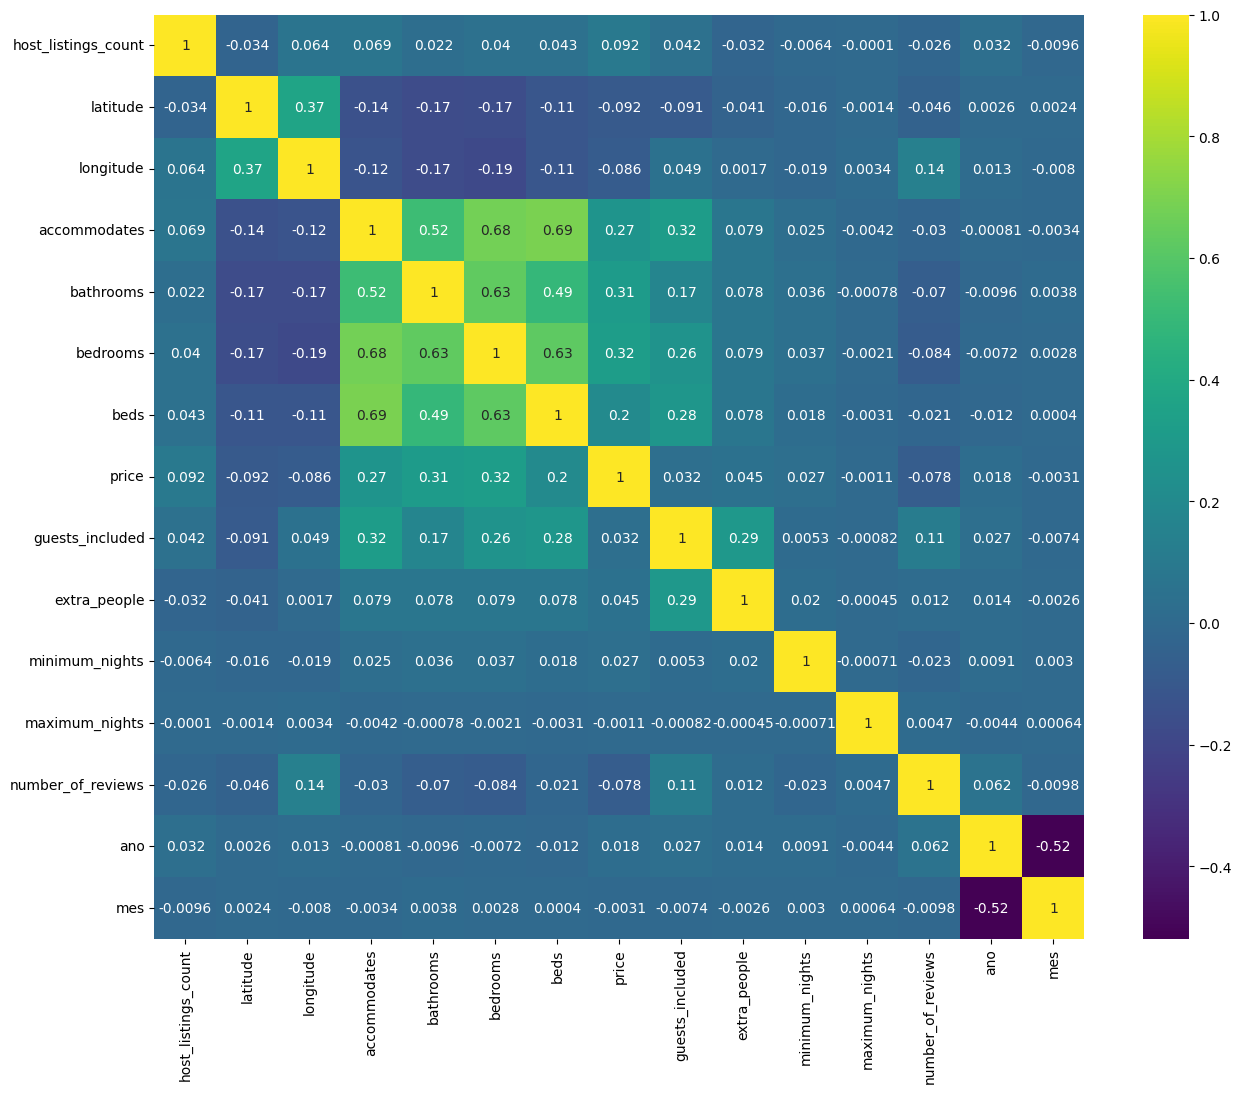

In [15]:
plt.figure(figsize=(15,12))
sns.heatmap(base_airbnb.corr(numeric_only=True), annot=True, cmap='viridis')
plt.show()

### Definição de funções para análise de outliers

Vamos definir algumas funções para ajudar na análise de outliers das colunas

In [16]:
def limites(coluna):
    q1 = coluna.quantile(0.25)
    q3 = coluna.quantile(0.75)
    amplitude = q3- q1
    return q1 - 1.5 * amplitude, q3 + 1.5 * amplitude

def excluir_outliers(df, nome_coluna):
    qtde_linhas = base_airbnb.shape[0]
    lim_inf, lim_sup = limites(df[nome_coluna])
    df = df.loc[(df[nome_coluna] >= lim_inf) & (df[nome_coluna] <= lim_sup), :]
    linhas_removidas = qtde_linhas - df.shape[0] 
    return df, linhas_removidas

In [17]:
print(limites(base_airbnb['price']))

(np.float64(-524.0), np.float64(1276.0))


In [18]:
def diagrama_caixa(coluna):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(15,5)
    sns.boxplot(x= coluna, ax = ax1)
    ax2.set_xlim(limites(coluna))
    sns.boxplot(x= coluna, ax = ax2)

def histograma(coluna):
    plt.figure(figsize=(15,5))
    sns.histplot(coluna, kde = True)
    plt.show()

def grafico_barra(coluna):
    plt.figure(figsize=(15,5))
    ax = sns.barplot(x=coluna.value_counts().index, y = coluna.value_counts())
    ax.set_xlim(limites(coluna))

#### Analisando a coluna Price

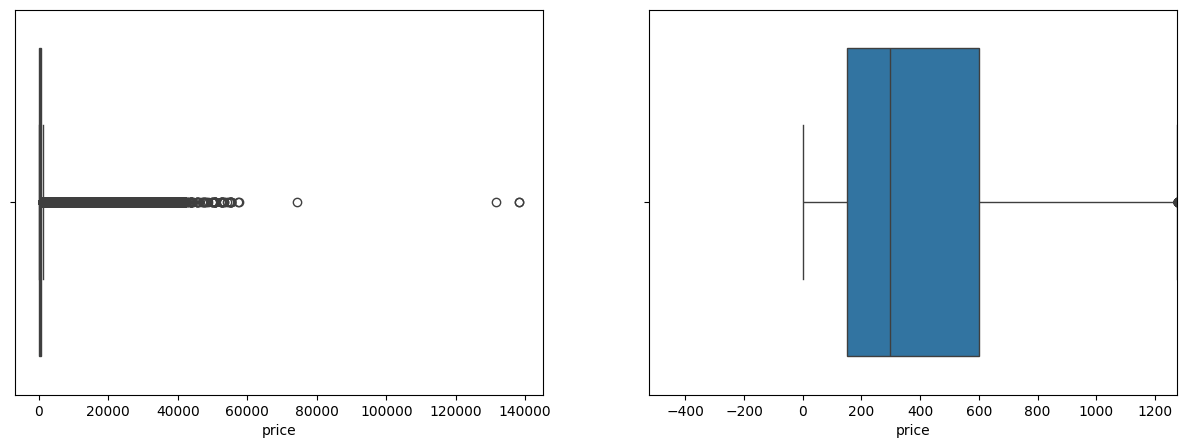

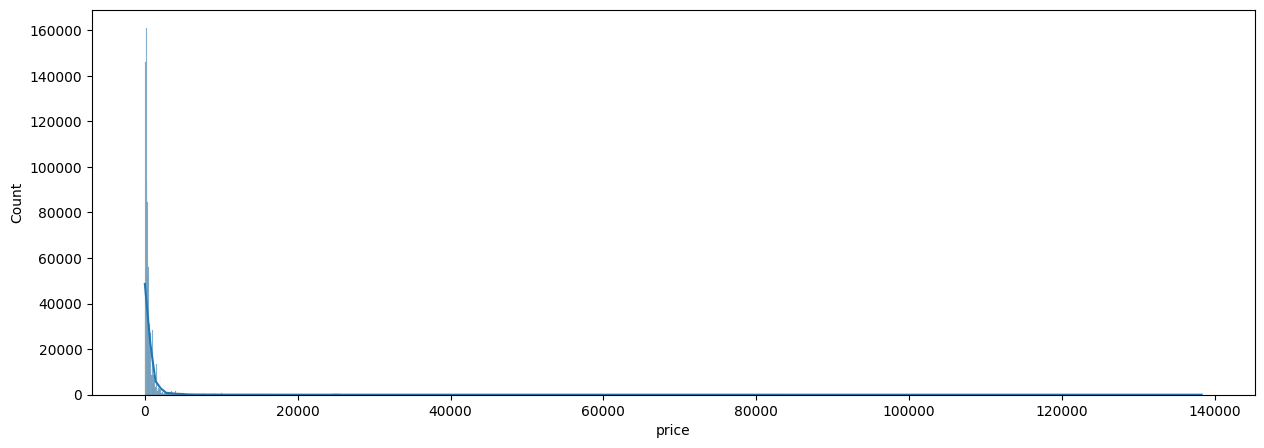

In [19]:
diagrama_caixa(base_airbnb['price'])
histograma(base_airbnb['price'])

Como estamos construindo um modelo para imóveis comuns, acredito que os valores acima do limite superior serão apenas de imóveis de altíssimo luxo, que não é nosso objetivo principal. Por isso, podemos excluir esses outliers.

In [20]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'price')
print(f'Foram removidas {linhas_removidas} na coluna price')

Foram removidas 87282 na coluna price


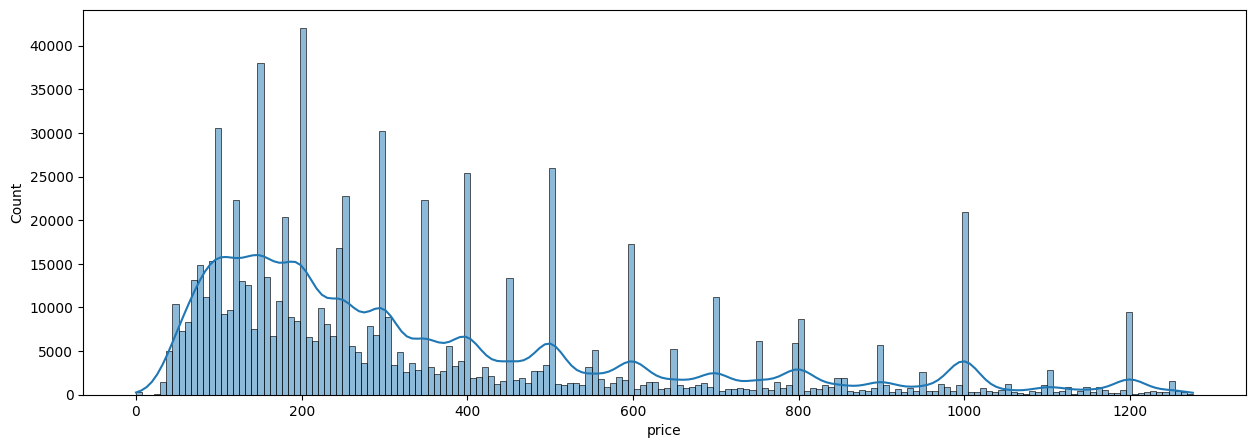

In [21]:
histograma(base_airbnb['price'])

#### Analisando a coluna extra_people


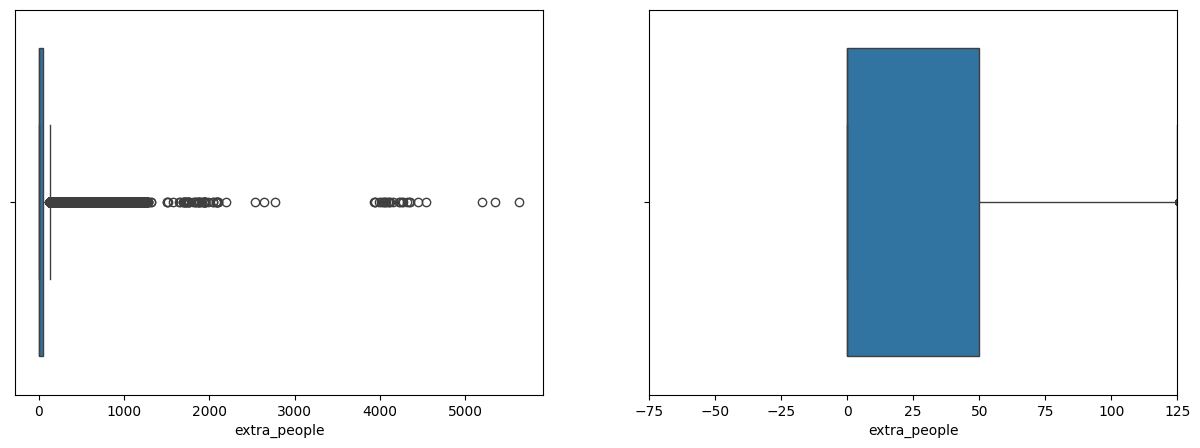

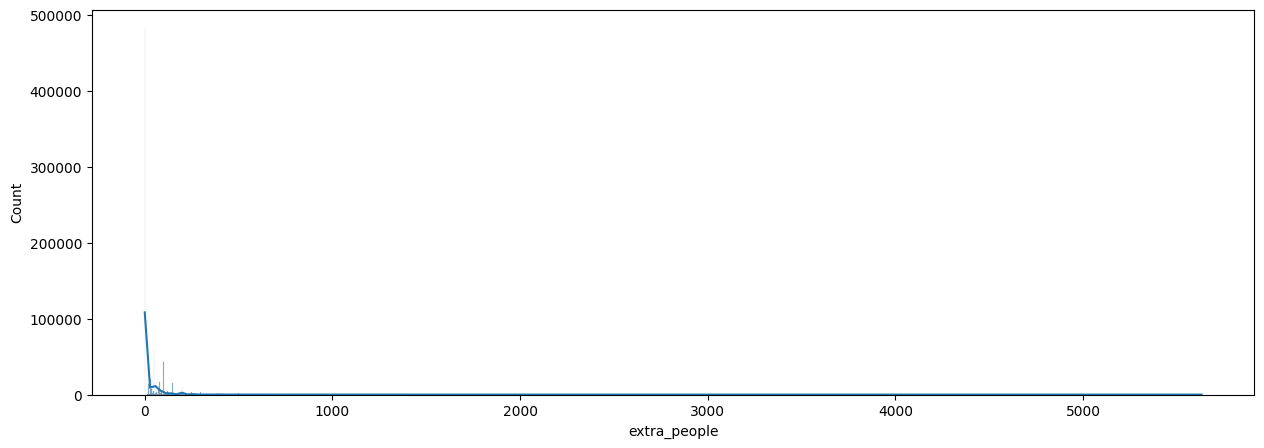

In [22]:
diagrama_caixa(base_airbnb['extra_people'])
histograma(base_airbnb['extra_people'])

In [23]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'extra_people')
print(f'Foram removidas {linhas_removidas} linhas')

Foram removidas 59194 linhas


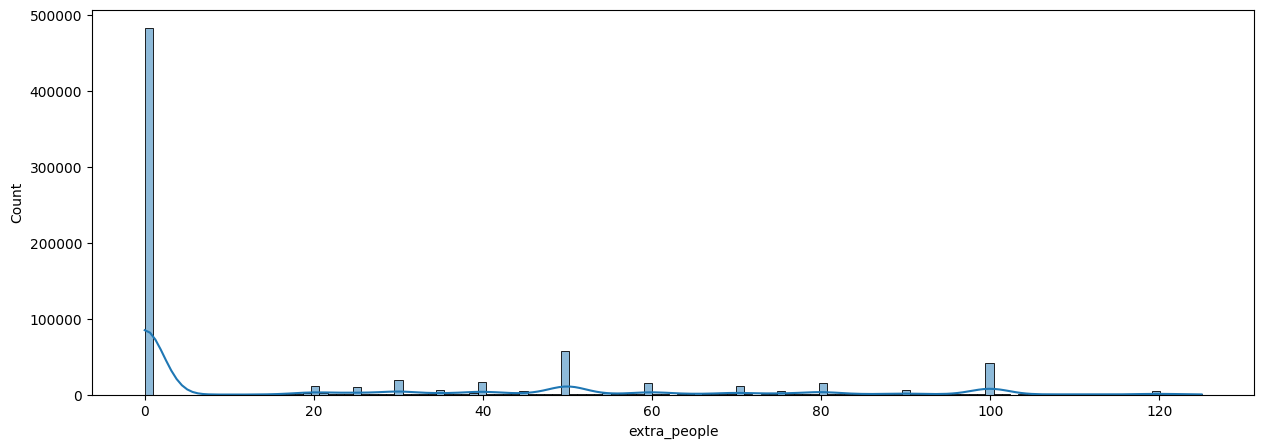

In [24]:
histograma(base_airbnb['extra_people'])

#### Host Listings Count

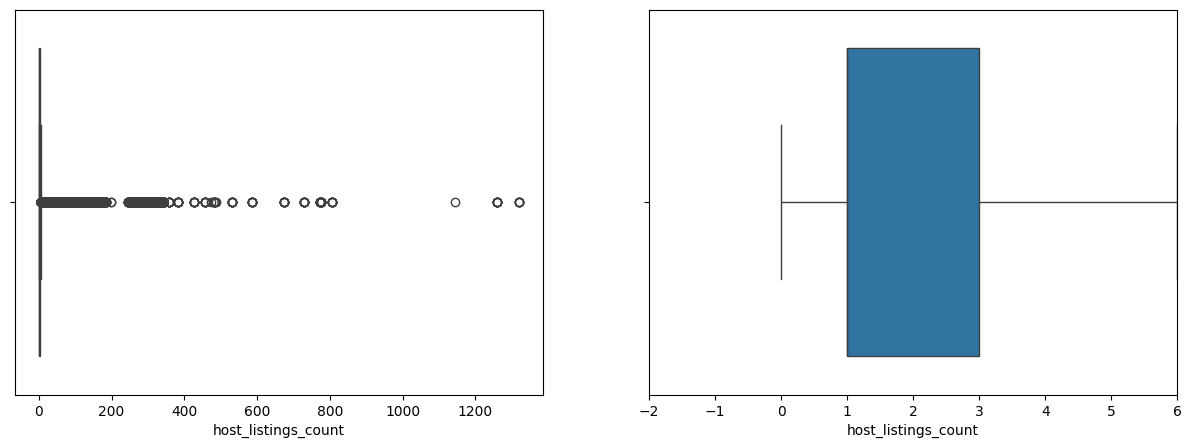

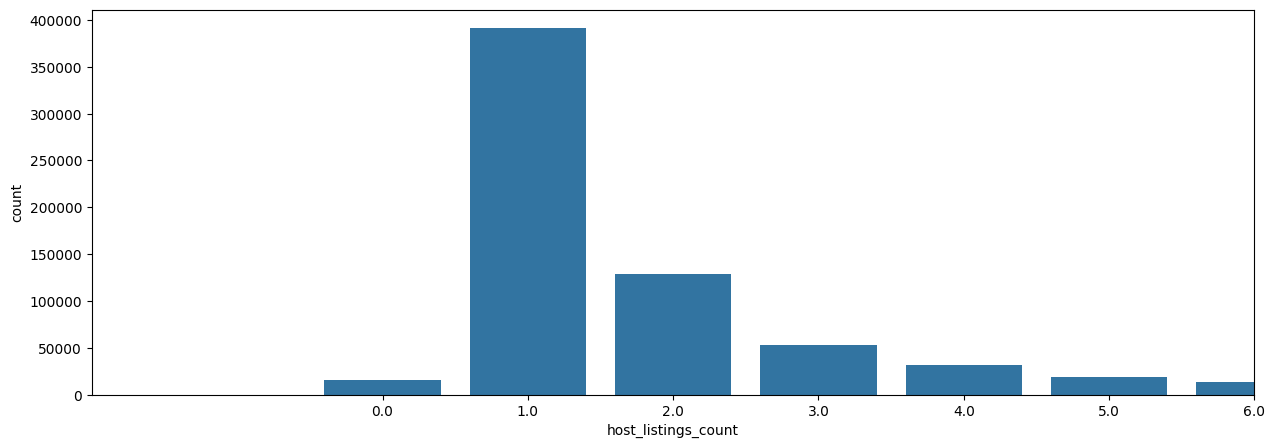

In [25]:
diagrama_caixa(base_airbnb['host_listings_count'])
grafico_barra(base_airbnb['host_listings_count'])

É pertinente excluir os outliers, uma vez que hosts com mais de 6 imóveis no AirBnB não são o público alvo do projeto, uma vez que seriam imobiliárias ou pessoas que gerenciam imóveis no AirBnB

In [26]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'host_listings_count')
print(f'Foram removidas {linhas_removidas} linhas')

Foram removidas 97723 linhas


#### accommodates    

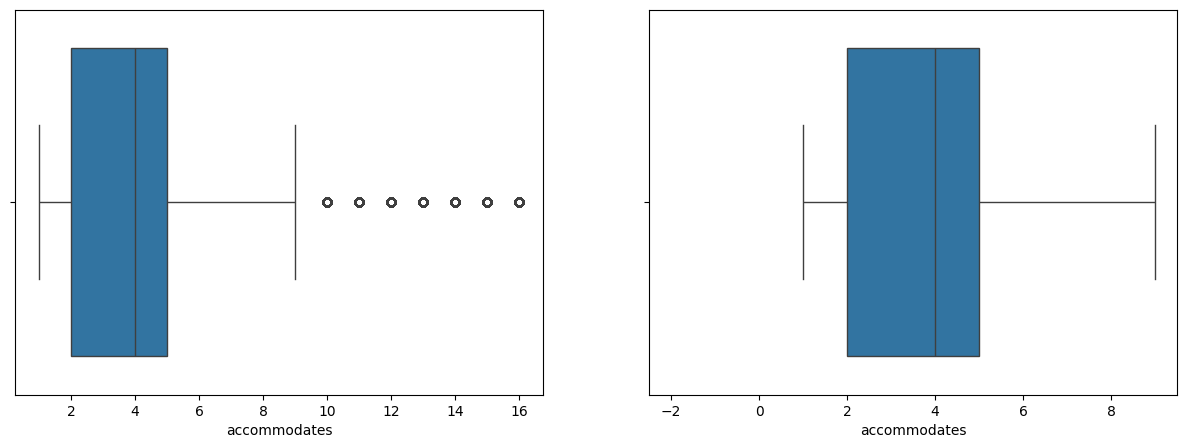

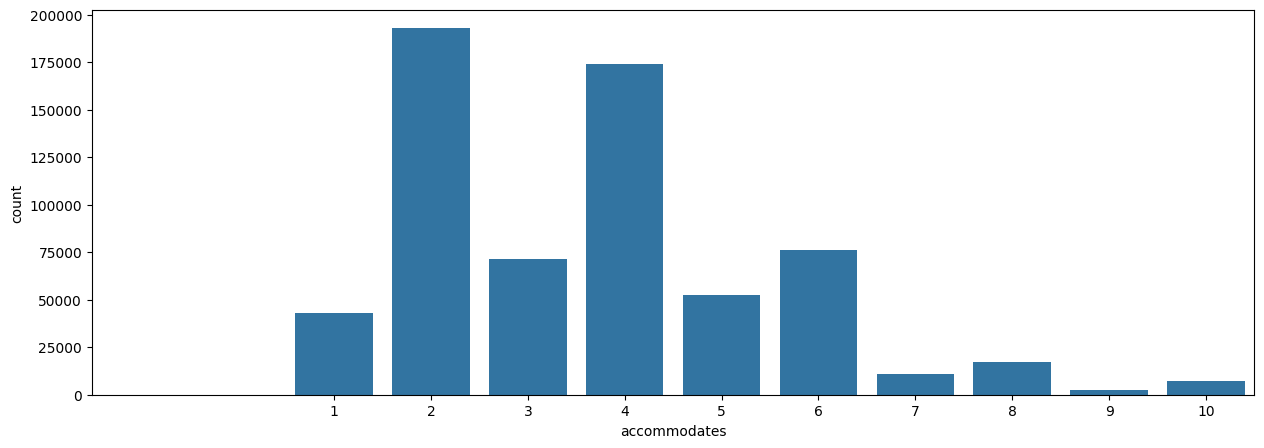

In [27]:
diagrama_caixa(base_airbnb['accommodates'])
grafico_barra(base_airbnb['accommodates'])

In [28]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'accommodates')
print(f'Foram removidas {linhas_removidas} linhas')

Foram removidas 13146 linhas


#### bathrooms

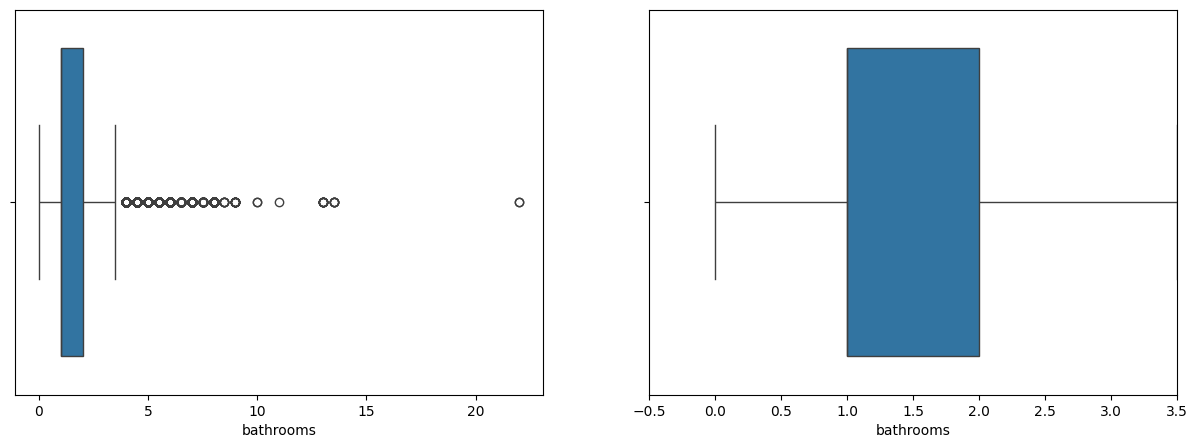

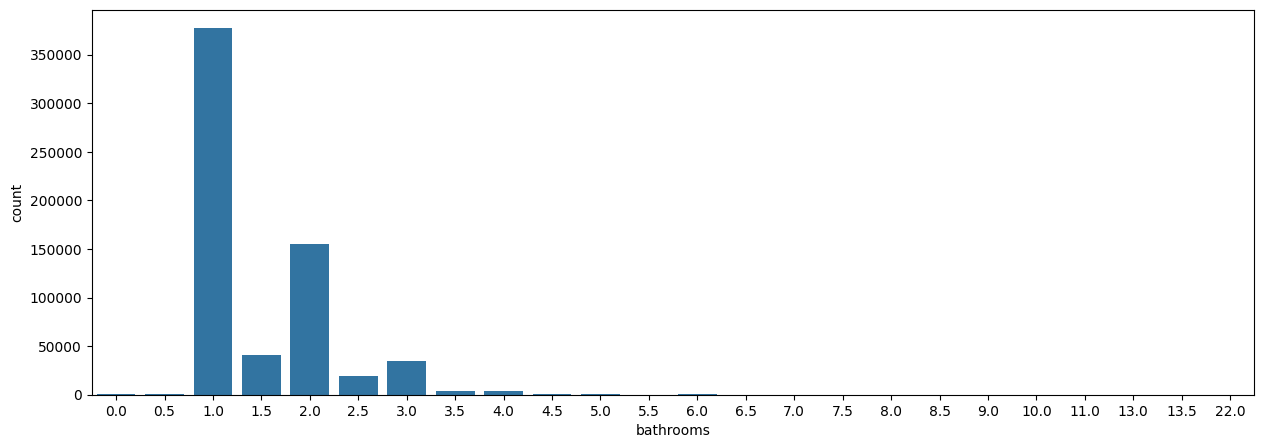

In [29]:
diagrama_caixa(base_airbnb['bathrooms'])
plt.figure(figsize=(15,5))
sns.barplot(x= base_airbnb['bathrooms'].value_counts().index, y= base_airbnb['bathrooms'].value_counts())
plt.show()

In [30]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'bathrooms')
print(f'Foram removidas {linhas_removidas} linhas')

Foram removidas 6894 linhas


#### bedrooms  

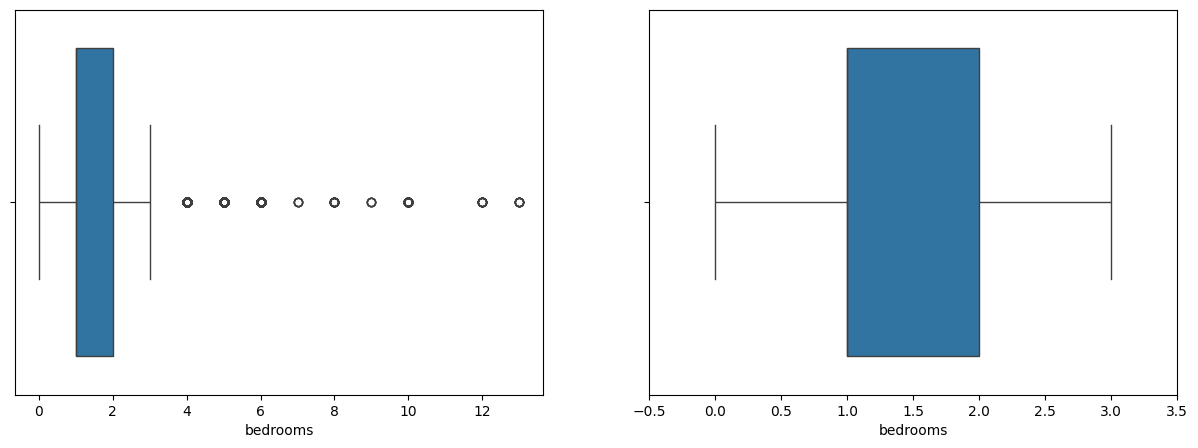

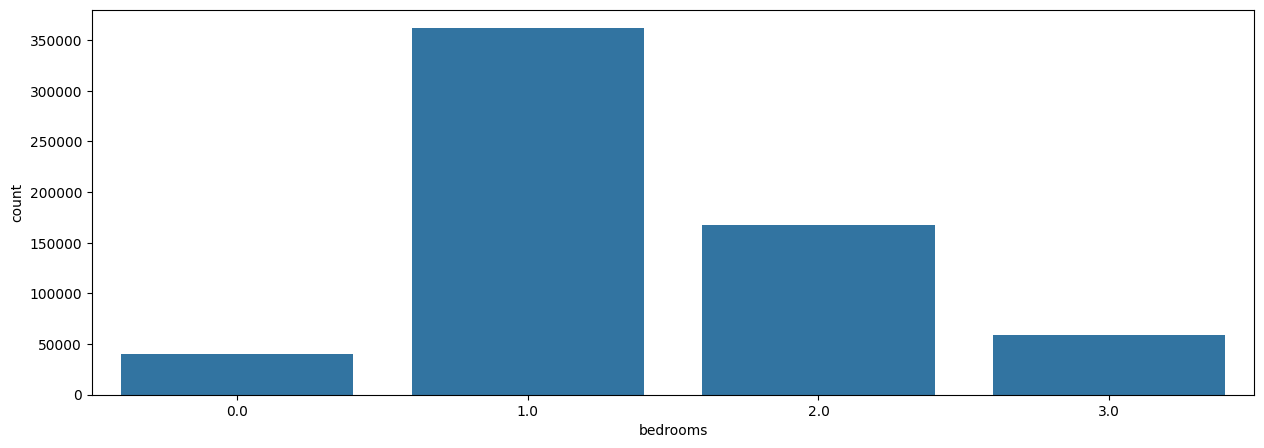

In [31]:
diagrama_caixa(base_airbnb['bedrooms'])
grafico_barra(base_airbnb['bedrooms'])

In [32]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'bedrooms')
print(f'Foram removidas {linhas_removidas} linhas')

Foram removidas 5482 linhas


#### beds 

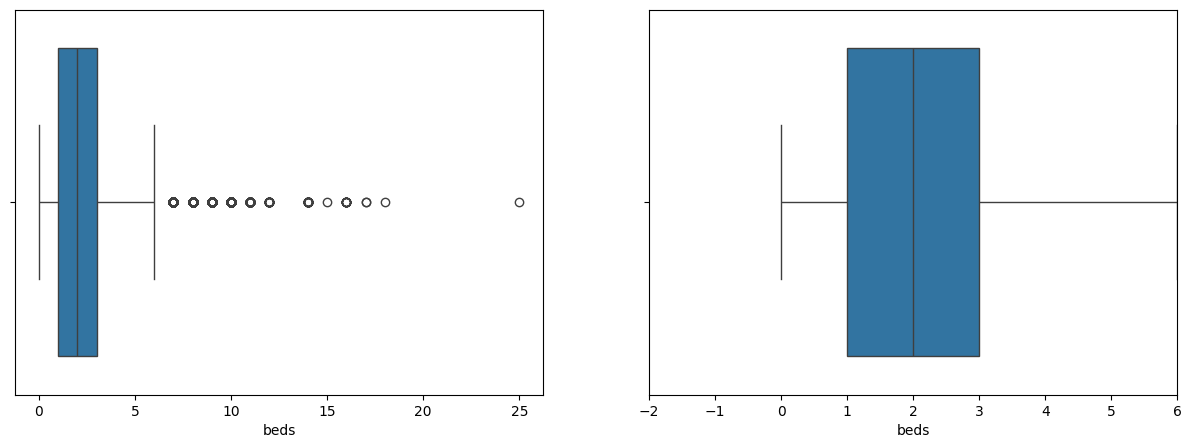

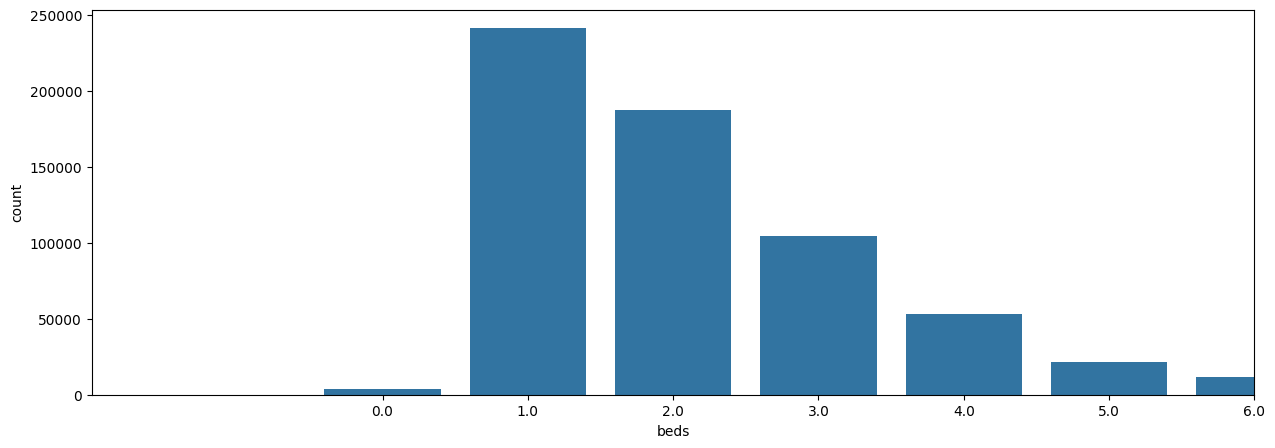

In [33]:
diagrama_caixa(base_airbnb['beds'])
grafico_barra(base_airbnb['beds'])

In [34]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'beds')
print(f'Foram removidas {linhas_removidas} linhas')

Foram removidas 5622 linhas


#### guests_included  

C:\Users\Arthur Lindolpho\AppData\Local\Temp\ipykernel_16724\2141666009.py:5: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax2.set_xlim(limites(coluna))
C:\Users\Arthur Lindolpho\AppData\Local\Temp\ipykernel_16724\2141666009.py:16: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(limites(coluna))


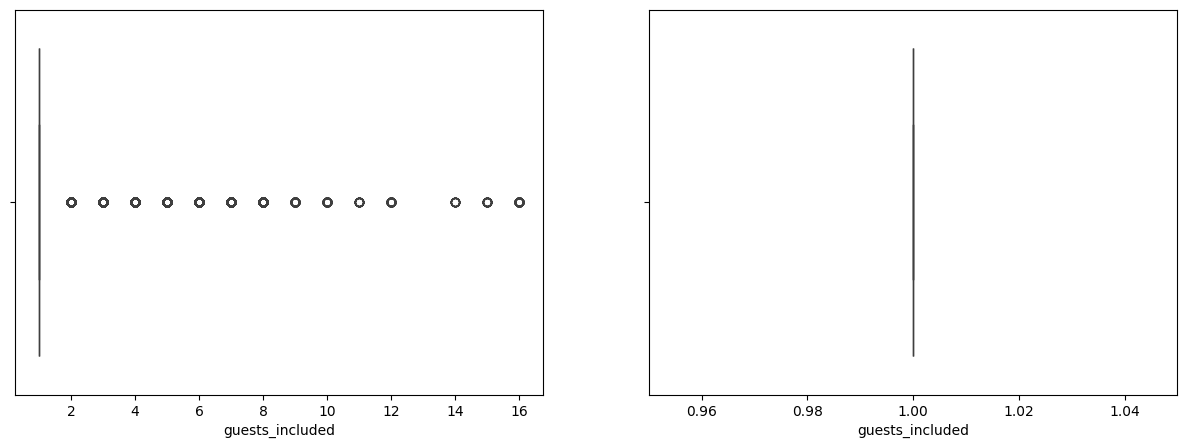

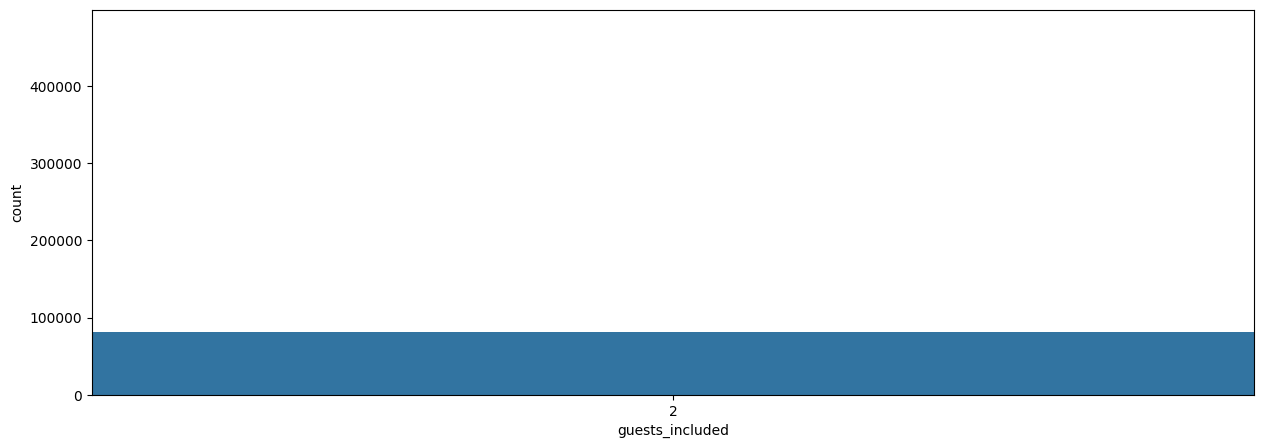

In [35]:
diagrama_caixa(base_airbnb['guests_included'])
grafico_barra(base_airbnb['guests_included'])

In [36]:
print(limites(base_airbnb['guests_included']))

(np.float64(1.0), np.float64(1.0))


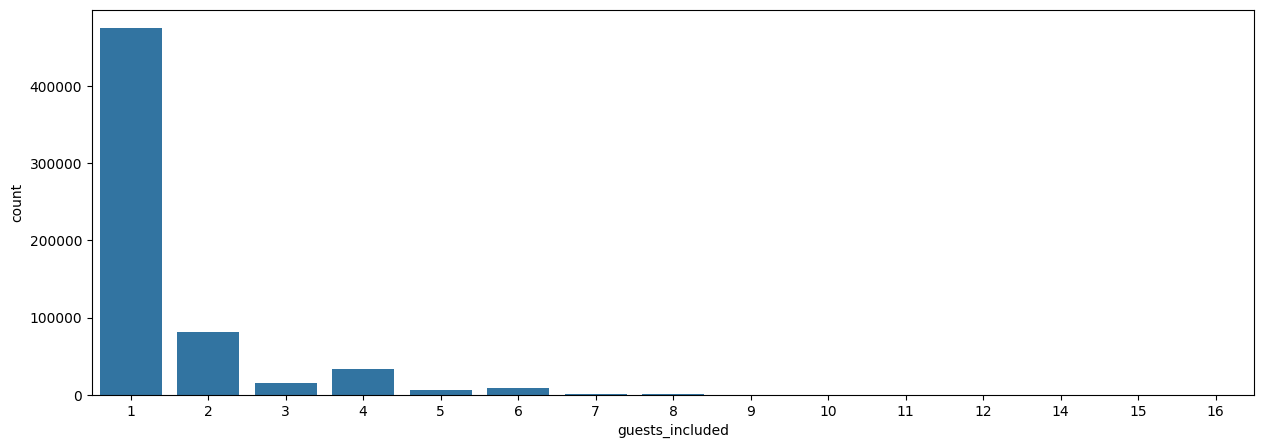

In [37]:
plt.figure(figsize=(15,5))
sns.barplot(x= base_airbnb['guests_included'].value_counts().index, y= base_airbnb['guests_included'].value_counts())
plt.show()

Irei remover a coluna guests included do meu dataset, pois parece que os usuários do AirBnB não preenchem corretamente este campo e utilizam o valor padrão da plataforma, sendo assim, se fossemos remover os outliers desta coluna, teríamos uma perda significativa de registros e de informações relevantes, o que atrapalharia o modelo.

In [38]:
base_airbnb = base_airbnb.drop('guests_included', axis = 1)

In [39]:
base_airbnb.shape

(622366, 22)

#### minimum_nights

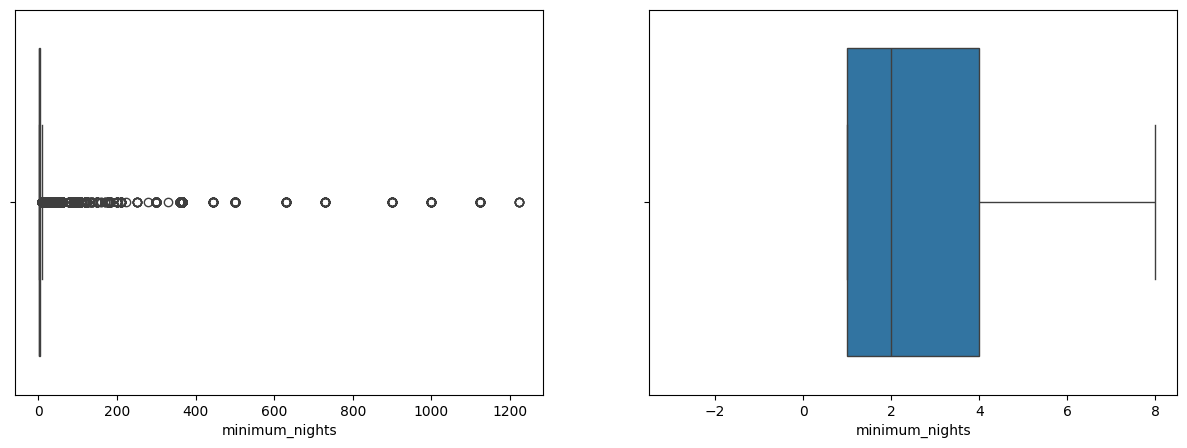

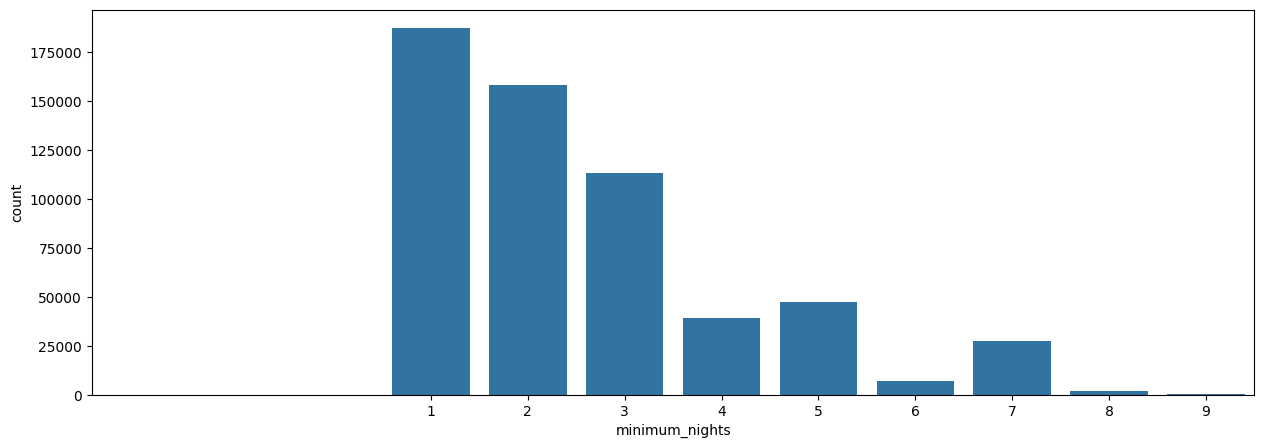

In [40]:
diagrama_caixa(base_airbnb['minimum_nights'])
grafico_barra(base_airbnb['minimum_nights'])

In [41]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'minimum_nights')
print(f'Foram removidas {linhas_removidas} linhas')

Foram removidas 40383 linhas


#### maximum_nights

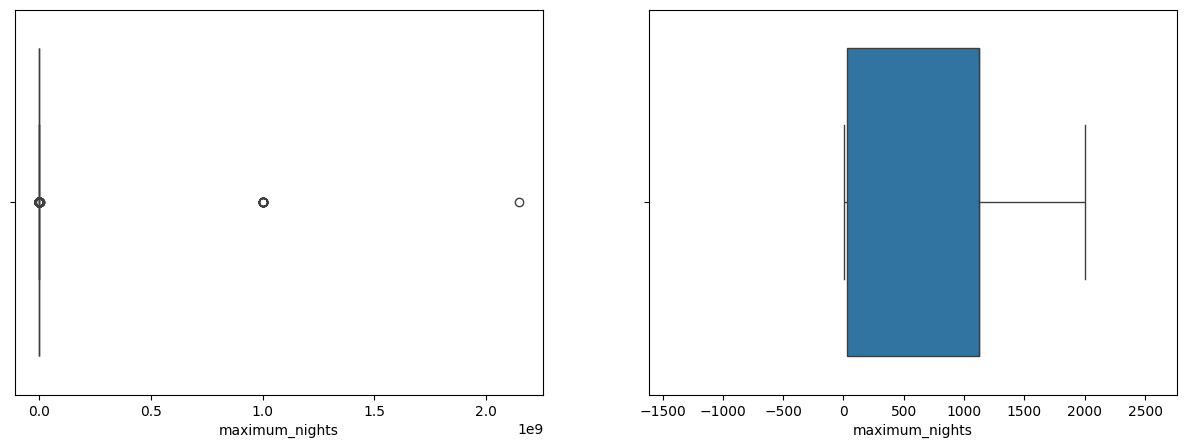

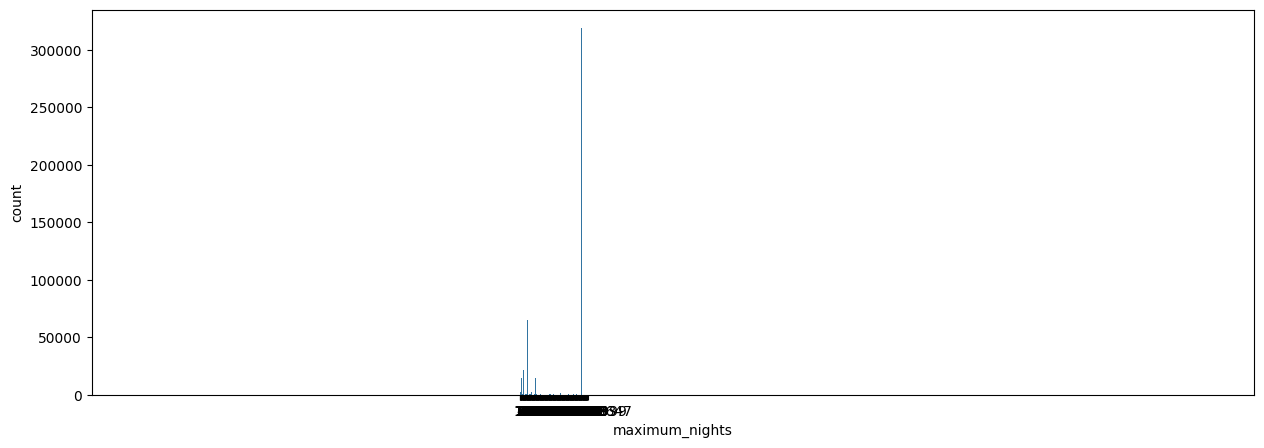

In [42]:
diagrama_caixa(base_airbnb['maximum_nights'])
grafico_barra(base_airbnb['maximum_nights'])

Após a análise desses gráficos podemos perceber que o número máximo de noites não é uma característica muito relevante para o nosso modelo, uma vez que muitos usuários nem preencheram este campo, sendo assim, vamos retirar essa coluna.

In [43]:
base_airbnb = base_airbnb.drop('maximum_nights', axis=1)

#### number_of_reviews

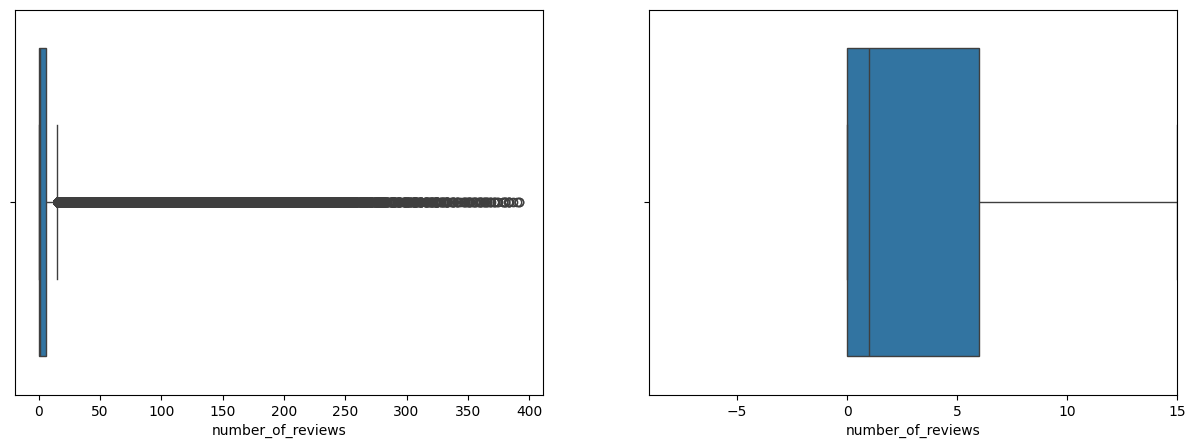

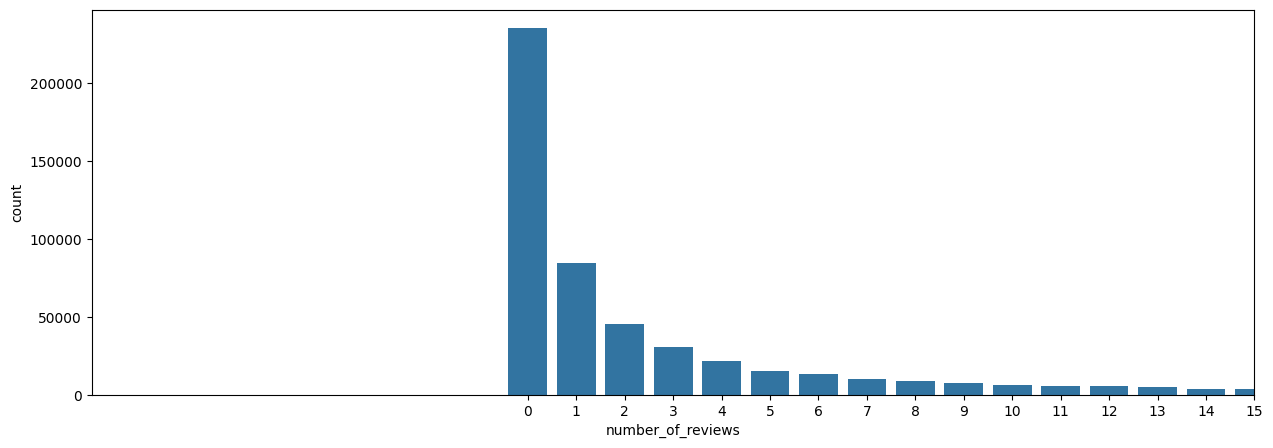

In [44]:
diagrama_caixa(base_airbnb['number_of_reviews'])
grafico_barra(base_airbnb['number_of_reviews'])

Como o objetivo deste projeto é auxiliar novos hosts no AirBnB a precificar a diária de seus imóveis, o número de avaliações que aquele host recebeu não deve ser uma feature levada em consideração, uma vez que novos hosts não vão ter avaliações e seriam de certa forma "penalizados" pelo modelo, o objetivo é criar um modelo de ML que consiga generealizar bem sem essa feature.

Além disso, se fossemos remover os outliers desta feature, iríamos remover um número muito grande de registros.

In [45]:
base_airbnb = base_airbnb.drop('number_of_reviews', axis=1)

In [46]:
base_airbnb.shape

(581983, 20)

In [47]:
base_airbnb.head(5)

,host_is_superhost,host_listings_count,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,amenities,price,extra_people,minimum_nights,instant_bookable,is_business_travel_ready,cancellation_policy,ano,mes
1,t,2.0,-22.965919,-43.178962,Condominium,Entire home/apt,5,1.0,2.0,2.0,Real Bed,"{TV,""Cable TV"",Internet,Wifi,""Air conditioning...",270.0,51.0,4,t,f,strict,2018,4
3,f,3.0,-22.977117,-43.190454,Apartment,Entire home/apt,3,1.0,1.0,2.0,Real Bed,"{TV,""Cable TV"",Internet,Wifi,""Air conditioning...",161.0,45.0,4,f,f,strict,2018,4
4,t,1.0,-22.983024,-43.214270,Apartment,Entire home/apt,3,1.0,1.0,2.0,Real Bed,"{TV,""Cable TV"",Internet,Wifi,""Air conditioning...",222.0,68.0,2,t,f,strict,2018,4
5,t,1.0,-22.988165,-43.193588,Apartment,Entire home/apt,3,1.5,1.0,2.0,Real Bed,"{TV,""Cable TV"",Internet,Wifi,""Air conditioning...",308.0,86.0,2,f,f,strict,2018,4
6,t,1.0,-22.981269,-43.190457,Loft,Entire home/apt,2,1.0,1.0,2.0,Real Bed,"{TV,""Cable TV"",Wifi,""Air conditioning"",Kitchen...",219.0,80.0,3,t,f,strict,2018,4


In [48]:
print(base_airbnb.dtypes)

host_is_superhost            object
host_listings_count         float64
latitude                    float64
longitude                   float64
property_type                object
room_type                    object
accommodates                  int64
bathrooms                   float64
bedrooms                    float64
beds                        float64
bed_type                     object
amenities                    object
price                       float32
extra_people                float32
minimum_nights                int64
instant_bookable             object
is_business_travel_ready     object
cancellation_policy          object
ano                           int64
mes                           int64
dtype: object


### Tratamento de colunas de valores de texto

#### property_type

In [49]:
print(base_airbnb['property_type'].value_counts())

property_type
Apartment                 458354
House                      51387
Condominium                26456
Serviced apartment         12671
Loft                       12352
Guest suite                 3621
Bed and breakfast           3472
Hostel                      2665
Guesthouse                  2155
Other                       1957
Villa                       1294
Townhouse                    969
Aparthotel                   693
Chalet                       481
Earth house                  468
Tiny house                   457
Boutique hotel               447
Hotel                        376
Casa particular (Cuba)       298
Cottage                      230
Bungalow                     207
Dorm                         185
Cabin                        141
Nature lodge                 124
Castle                        80
Treehouse                     76
Island                        54
Boat                          53
Hut                           40
Campsite                     

In [50]:
tabela_tipos_casa = base_airbnb['property_type'].value_counts()
colunas_agrupar = []

for tipo in tabela_tipos_casa.index:
    if tabela_tipos_casa[tipo] < 10000:
        colunas_agrupar.append(tipo)
print(colunas_agrupar)

for tipo in colunas_agrupar:
    base_airbnb.loc[base_airbnb['property_type']==tipo,'property_type'] = 'Outros'

print(base_airbnb['property_type'].value_counts())

['Guest suite', 'Bed and breakfast', 'Hostel', 'Guesthouse', 'Other', 'Villa', 'Townhouse', 'Aparthotel', 'Chalet', 'Earth house', 'Tiny house', 'Boutique hotel', 'Hotel', 'Casa particular (Cuba)', 'Cottage', 'Bungalow', 'Dorm', 'Cabin', 'Nature lodge', 'Castle', 'Treehouse', 'Island', 'Boat', 'Hut', 'Campsite', 'Resort', 'Camper/RV', 'Yurt', 'Tent', 'Tipi', 'Barn', 'Farm stay', 'Pension (South Korea)', 'Dome house', 'In-law', 'Igloo', 'Vacation home', 'Timeshare', 'Pousada', 'Houseboat', 'Casa particular', 'Plane']
property_type
Apartment             458354
House                  51387
Condominium            26456
Outros                 20763
Serviced apartment     12671
Loft                   12352
Name: count, dtype: int64


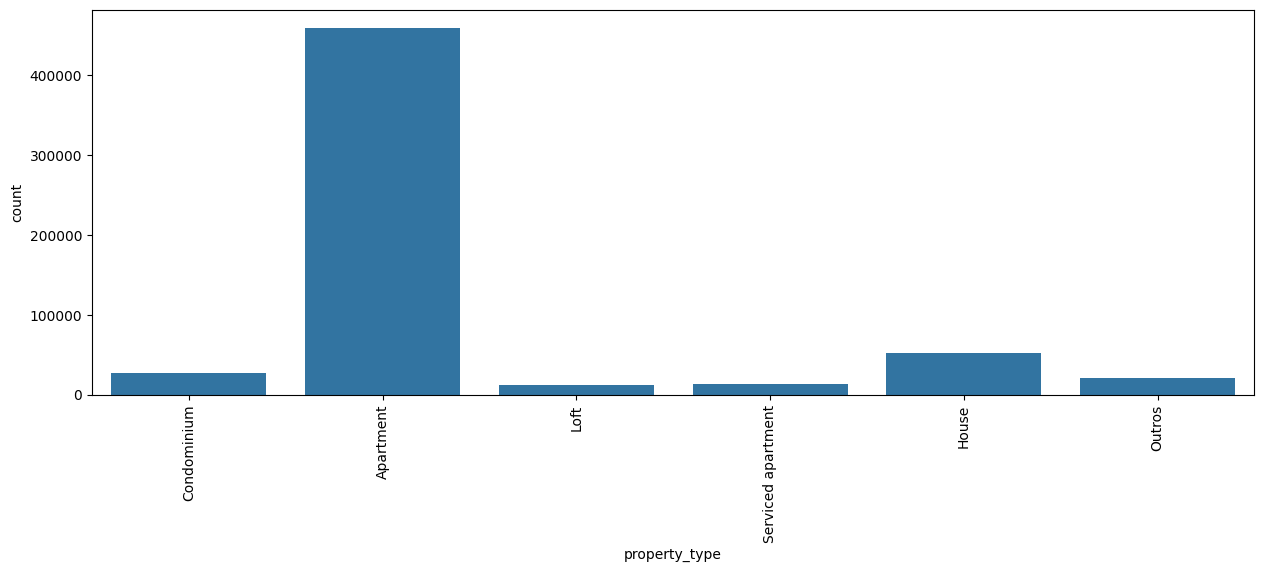

In [51]:
plt.figure(figsize=(15,5))
grafico = sns.countplot(x = 'property_type', data= base_airbnb)
grafico.tick_params(axis = 'x', rotation = 90)

#### room_type

In [52]:
print(base_airbnb['room_type'].value_counts())

room_type
Entire home/apt    372443
Private room       196859
Shared room         11714
Hotel room            967
Name: count, dtype: int64


C:\Users\Arthur Lindolpho\AppData\Local\Temp\ipykernel_16724\2028999371.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'room_type', data= base_airbnb, palette='viridis')


<Axes: xlabel='room_type', ylabel='count'>

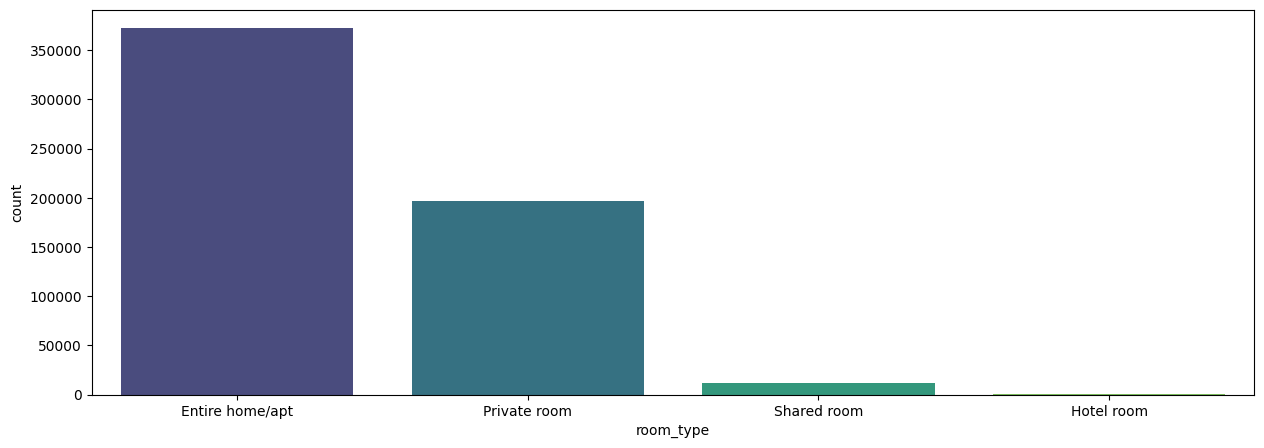

In [53]:
plt.figure(figsize=(15,5))
sns.countplot(x = 'room_type', data= base_airbnb, palette='viridis')


#### bed_type

In [54]:
print(base_airbnb['bed_type'].value_counts())

bed_type
Real Bed         570643
Pull-out Sofa      8055
Futon              1634
Airbed             1155
Couch               496
Name: count, dtype: int64


<Axes: xlabel='bed_type', ylabel='count'>

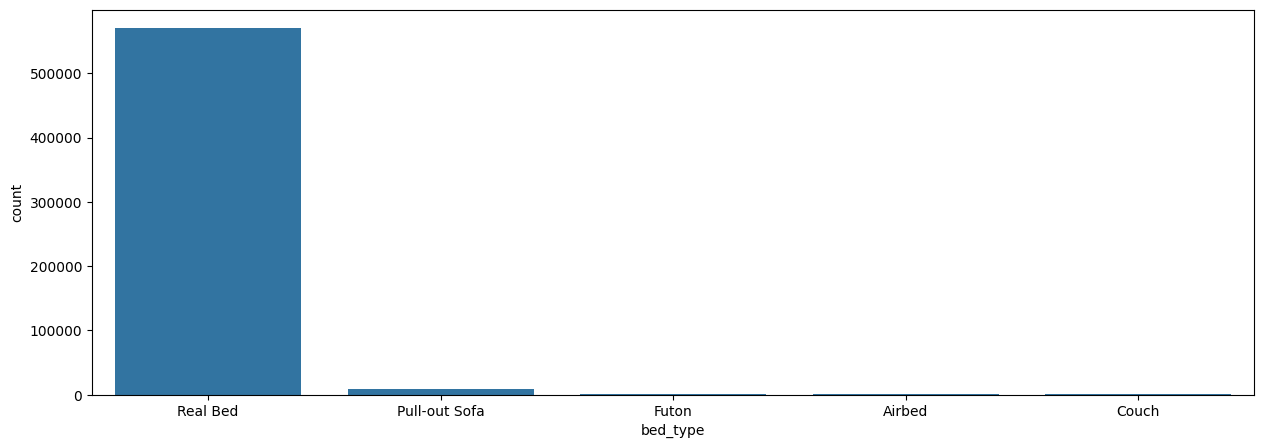

In [55]:
plt.figure(figsize=(15,5))
sns.countplot(x = 'bed_type', data= base_airbnb)

In [56]:
#Agrupando categorias de bed type

tabela_tipos_cama = base_airbnb['bed_type'].value_counts()
colunas_agrupar = []

for tipo in tabela_tipos_cama.index:
    if tabela_tipos_cama[tipo] < 10000:
        colunas_agrupar.append(tipo)
print(colunas_agrupar)

for tipo in colunas_agrupar:
    base_airbnb.loc[base_airbnb['bed_type']==tipo,'bed_type'] = 'Other'

print(base_airbnb['bed_type'].value_counts())

['Pull-out Sofa', 'Futon', 'Airbed', 'Couch']
bed_type
Real Bed    570643
Other        11340
Name: count, dtype: int64


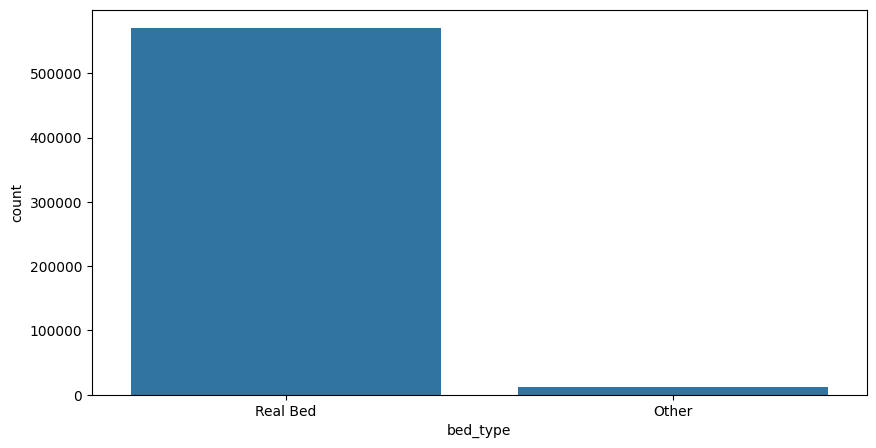

In [57]:
plt.figure(figsize=(10,5))
sns.countplot(x = 'bed_type', data= base_airbnb)
plt.show()

#### cancelation_policy

In [58]:
print(base_airbnb['cancellation_policy'].value_counts())

cancellation_policy
flexible                       258096
strict_14_with_grace_period    200743
moderate                       113281
strict                           9696
super_strict_60                   135
super_strict_30                    32
Name: count, dtype: int64


<Axes: xlabel='cancellation_policy', ylabel='count'>

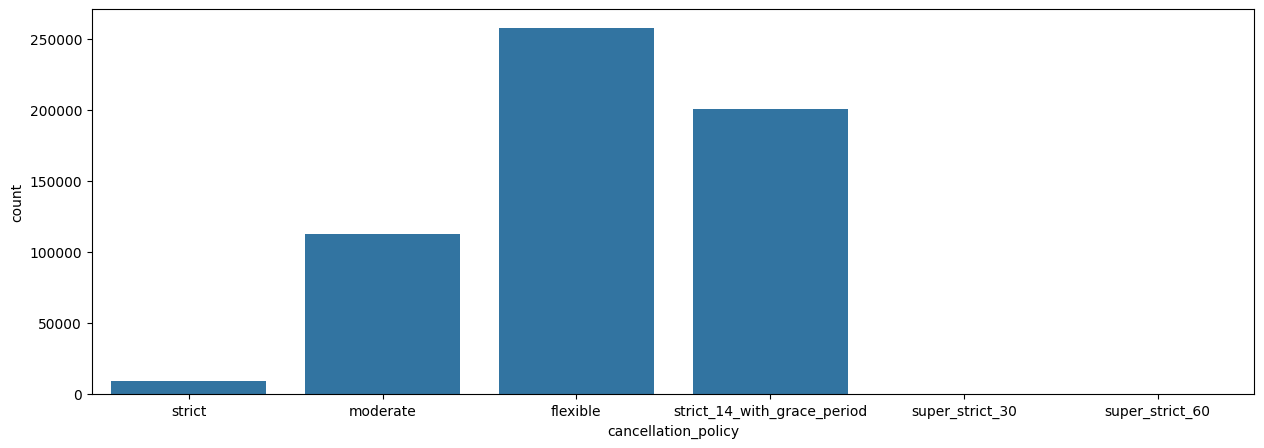

In [59]:
plt.figure(figsize=(15,5))
sns.countplot(x = 'cancellation_policy', data = base_airbnb)

In [60]:
#Agrupando valores de cancellation_policy

tabela_tipos_cancelamento = base_airbnb['cancellation_policy'].value_counts()
colunas_agrupar = []

for tipo in tabela_tipos_cancelamento.index:
    if tabela_tipos_cancelamento[tipo] < 10000:
        colunas_agrupar.append(tipo)
print(colunas_agrupar)

for tipo in colunas_agrupar:
    base_airbnb.loc[base_airbnb['cancellation_policy']==tipo,'cancellation_policy'] = 'Strict'

print(base_airbnb['cancellation_policy'].value_counts())

['strict', 'super_strict_60', 'super_strict_30']
cancellation_policy
flexible                       258096
strict_14_with_grace_period    200743
moderate                       113281
Strict                           9863
Name: count, dtype: int64


<Axes: xlabel='cancellation_policy', ylabel='count'>

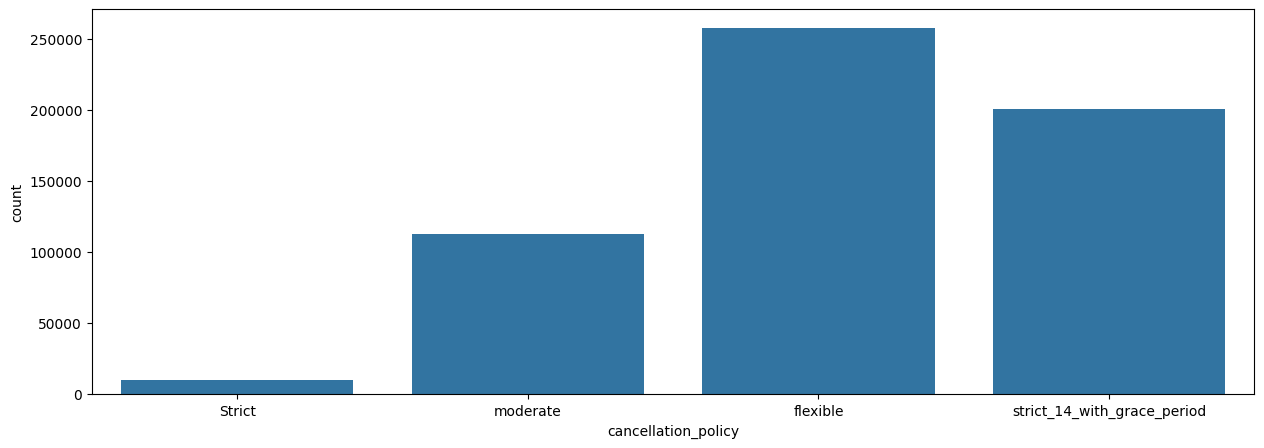

In [61]:
plt.figure(figsize=(15,5))
sns.countplot(x = 'cancellation_policy', data = base_airbnb)

#### amenities

In [62]:
print(base_airbnb['amenities'].value_counts())

amenities
{}                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    6012
{TV,"Cable TV",Internet,Wifi,"Air conditioning",Kitchen,Doorman,Elevator,"Buzzer/wireless intercom",Washer}                                                                                                                                                                                                                                                                                                                                                                        

Como temos uma diversidade muito grande de valores na coluna de amenities e, as vezes, as mesmas amenities podem ser escritas de maneiras diferentes, vamos avaliar a quantidade de comodidades e não cada uma isoladamente. Isso serve para padronizar nossos dados e fazer com que o modelo tenha mais facilidade em aprender algum padrão entre os dados.

In [63]:
print(base_airbnb['amenities'].iloc[1].split(','))
print(len(base_airbnb['amenities'].iloc[1].split(',')))

['{TV', '"Cable TV"', 'Internet', 'Wifi', '"Air conditioning"', 'Kitchen', 'Doorman', 'Elevator', '"Buzzer/wireless intercom"', '"Family/kid friendly"', 'Hangers', '"Hair dryer"', 'Iron', '"Laptop friendly workspace"}']
14


In [64]:
base_airbnb['n_amenities'] = base_airbnb['amenities'].str.split(',').apply(len)

In [65]:
base_airbnb = base_airbnb.drop('amenities', axis = 1)

Tratando numericamente a coluna n_amenities

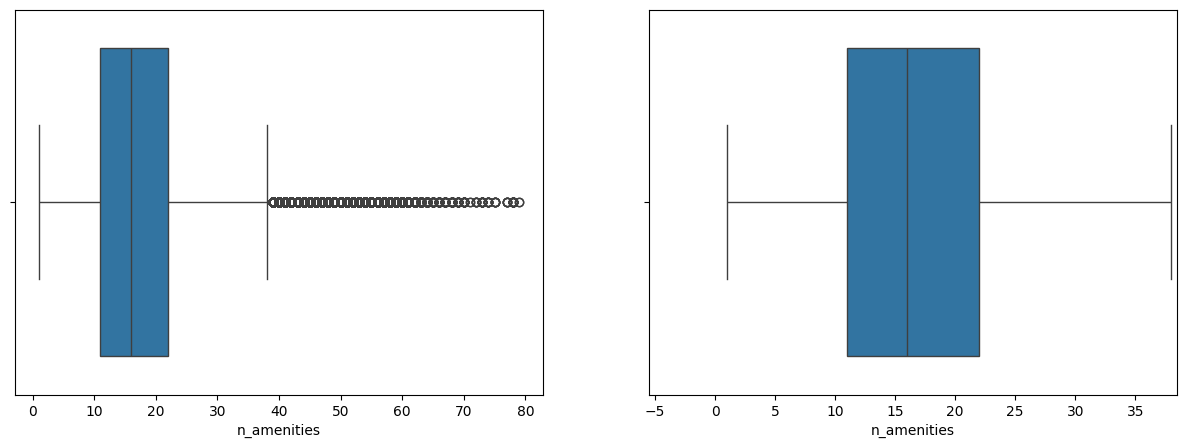

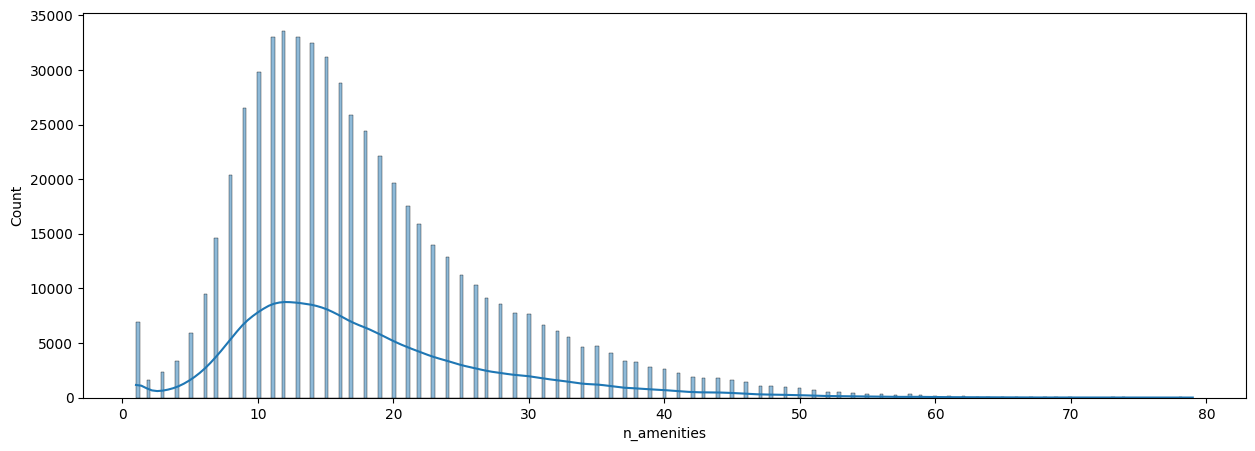

In [66]:
diagrama_caixa(base_airbnb['n_amenities'])
histograma(base_airbnb['n_amenities'])

In [67]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'n_amenities')
print(f'Foram removidas {linhas_removidas} linhas')

Foram removidas 24343 linhas


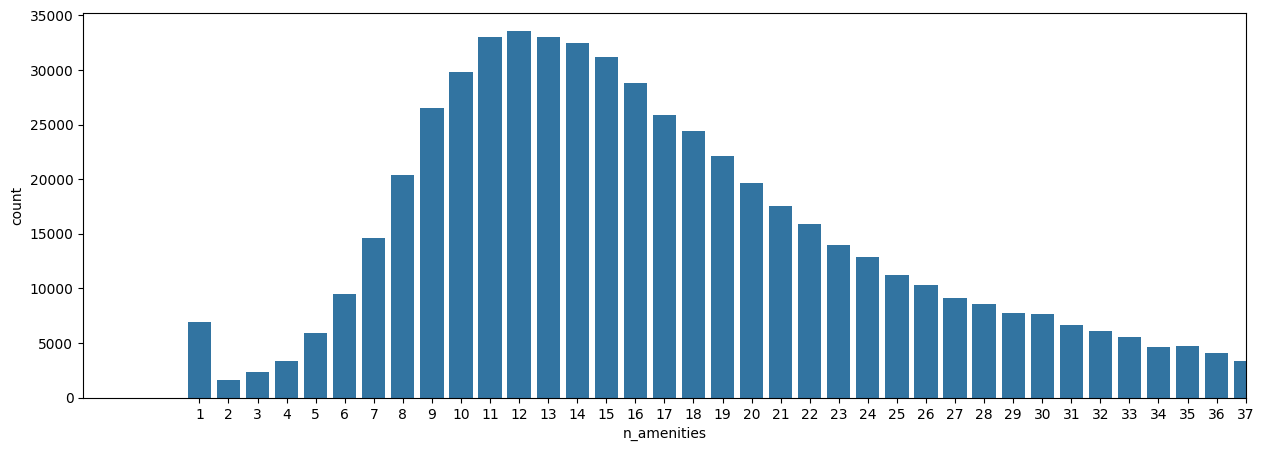

In [68]:
grafico_barra(base_airbnb['n_amenities'])

In [69]:
base_airbnb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 557640 entries, 1 to 34328
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   host_is_superhost         557640 non-null  object 
 1   host_listings_count       557640 non-null  float64
 2   latitude                  557640 non-null  float64
 3   longitude                 557640 non-null  float64
 4   property_type             557640 non-null  object 
 5   room_type                 557640 non-null  object 
 6   accommodates              557640 non-null  int64  
 7   bathrooms                 557640 non-null  float64
 8   bedrooms                  557640 non-null  float64
 9   beds                      557640 non-null  float64
 10  bed_type                  557640 non-null  object 
 11  price                     557640 non-null  float32
 12  extra_people              557640 non-null  float32
 13  minimum_nights            557640 non-null  int64  

### Visualização de mapa das propriedades

Nesta parte trabalharemos com as colunas de latitude e longitude

In [70]:
import sys 
import nbformat

In [71]:
#pegando uma amostra aleatória dos dados, para melhorar a visualização do mapa e deixar ele mais rápido 
amostra = base_airbnb.sample(n=50000)
centro_mapa = {'lat': amostra.latitude.mean(), 'lon':amostra.longitude.mean()}
fig = px.density_map(amostra, lat = 'latitude', lon='longitude', z= 'price', radius=2.5, center=centro_mapa, zoom=10, map_style='open-street-map', width=1200, height=800)
fig.show()

### Encoding

Para que o nosso modelo consiga trabalhar com as categorias que não são numéricas, vamos criar variáveis dummies, que consiste basicamente em dividir as features em cada classificação possível e atribuir a cada registro 1 ou 0, por exemplo, a feature beds, vamos criar duas colunas, real bed e outros, com isso, se o imóvel tiver camas, a coluna real bed recebe 1, se ele tiver colchões, sofá cama ou algo do tipo, recebe 0. E as features que tem valores como true or false, true será 1 e false será 0.

In [72]:
colunas_tf = ['host_is_superhost', 'instant_bookable', 'is_business_travel_ready']

In [73]:
base_airbnb_cod = base_airbnb.copy()
for coluna in colunas_tf:
    base_airbnb_cod.loc[base_airbnb_cod[coluna] == 't',coluna] = 1
    base_airbnb_cod.loc[base_airbnb_cod[coluna] == 'f',coluna] = 0
print(base_airbnb_cod.iloc[0])

host_is_superhost                         1
host_listings_count                     2.0
latitude                         -22.965919
longitude                        -43.178962
property_type                   Condominium
room_type                   Entire home/apt
accommodates                              5
bathrooms                               1.0
bedrooms                                2.0
beds                                    2.0
bed_type                           Real Bed
price                                 270.0
extra_people                           51.0
minimum_nights                            4
instant_bookable                          1
is_business_travel_ready                  0
cancellation_policy                  Strict
ano                                    2018
mes                                       4
n_amenities                              25
Name: 1, dtype: object


In [74]:
colunas_categorias = ['property_type', 'room_type', 'bed_type', 'cancellation_policy']

base_airbnb_cod = pd.get_dummies(data=base_airbnb_cod, columns=colunas_categorias, dtype='int8')

In [75]:
base_airbnb_cod.head()

,host_is_superhost,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,extra_people,...,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,bed_type_Other,bed_type_Real Bed,cancellation_policy_Strict,cancellation_policy_flexible,cancellation_policy_moderate,cancellation_policy_strict_14_with_grace_period
1,1,2.0,-22.965919,-43.178962,5,1.0,2.0,2.0,270.0,51.0,...,1,0,0,0,0,1,1,0,0,0
3,0,3.0,-22.977117,-43.190454,3,1.0,1.0,2.0,161.0,45.0,...,1,0,0,0,0,1,1,0,0,0
4,1,1.0,-22.983024,-43.214270,3,1.0,1.0,2.0,222.0,68.0,...,1,0,0,0,0,1,1,0,0,0
5,1,1.0,-22.988165,-43.193588,3,1.5,1.0,2.0,308.0,86.0,...,1,0,0,0,0,1,1,0,0,0
6,1,1.0,-22.981269,-43.190457,2,1.0,1.0,2.0,219.0,80.0,...,1,0,0,0,0,1,1,0,0,0


## Modelo de Previsão

### Os 7 passos para construir um modelo de previsão:

1. Definir se é classificação ou regressão (nesse caso será regressão);
2. Escolher as métricas para avaliar o modelo;
3. Escolher quais modelos vamos testar;
4. Treinar os modelos e testar;
5. Comparar os resultados dos modelos e escolher o melhor;
6. Analisar o melhor modelo mais a fundo;
7. Fazer ajustes no melhor modelo.

#### 1. Regressão

In [76]:
def avaliar_modelo(nome_modelo, y_teste, y_prev):
    r2 = r2_score(y_teste, y_prev)
    RMSE = np.sqrt(mean_squared_error(y_teste, y_prev))
    MAE = mean_absolute_error(y_teste, y_prev)
    return f'Modelo: {nome_modelo}\nR²: {r2:.2%}\nRMSE: {RMSE:.2f}\nMAE: {MAE :.2f}'

- Escolha dos modelos a serem testados:

    1. Linear Regressoin
    2. Random Forest
    3. Extra Tree

In [77]:
modelo_rf = RandomForestRegressor()
modelo_lr = LinearRegression()
modelo_et = ExtraTreesRegressor()
modelos = {'RandomForest': modelo_rf,
           'LinearRegression': modelo_lr,
           'ExtraTrees': modelo_et}

X = base_airbnb_cod.drop('price', axis=1)
y = base_airbnb_cod['price']

- Separando os dados

MUDAR ESSA PARTE, PEGAR MÉDIA E DESVIO PADRÃO

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10)
#Random state é como se fosse a semenete de reprodutibilidade, para não termos resultados resultados diferentes a cada rodada

for nome_modelo, modelo in modelos.items():
    #treinar
    modelo.fit(X_train, y_train)
    #testar
    y_prev = modelo.predict(X_test)
    print(avaliar_modelo(nome_modelo, y_test, y_prev))

Modelo: RandomForest
R²: 97.25%
RMSE: 44.01
MAE: 14.50
Modelo: LinearRegression
R²: 32.67%
RMSE: 217.60
MAE: 159.63
Modelo: ExtraTrees
R²: 97.49%
RMSE: 41.97
MAE: 11.54


Ao rodar os modelos da maneira mais simples possível vimos que os modelos que tiveram os melhores resultados foram os modelos Random Forest e Extra Trees, sendo assim, vamos aprofundar esses modelos para torná-los mais consistentes

### Análise do Melhor Modelo

In [79]:
for nome_modelo, modelo in modelos.items():
    #testar
    y_prev = modelo.predict(X_test)
    print(avaliar_modelo(nome_modelo, y_test, y_prev))

Modelo: RandomForest
R²: 97.25%
RMSE: 44.01
MAE: 14.50
Modelo: LinearRegression
R²: 32.67%
RMSE: 217.60
MAE: 159.63
Modelo: ExtraTrees
R²: 97.49%
RMSE: 41.97
MAE: 11.54


In [80]:
importancia_features = pd.DataFrame(modelo_et.feature_importances_, X_train.columns)
importancia_features = importancia_features.sort_values(by = 0, ascending=False)
display(importancia_features)

,0
bedrooms,0.113327
latitude,0.104707
longitude,0.101534
n_amenities,0.089406
extra_people,0.085882
accommodates,0.071981
bathrooms,0.069815
room_type_Entire home/apt,0.068077
minimum_nights,0.065705
beds,0.052953


C:\Users\Arthur Lindolpho\AppData\Local\Temp\ipykernel_16724\291078423.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




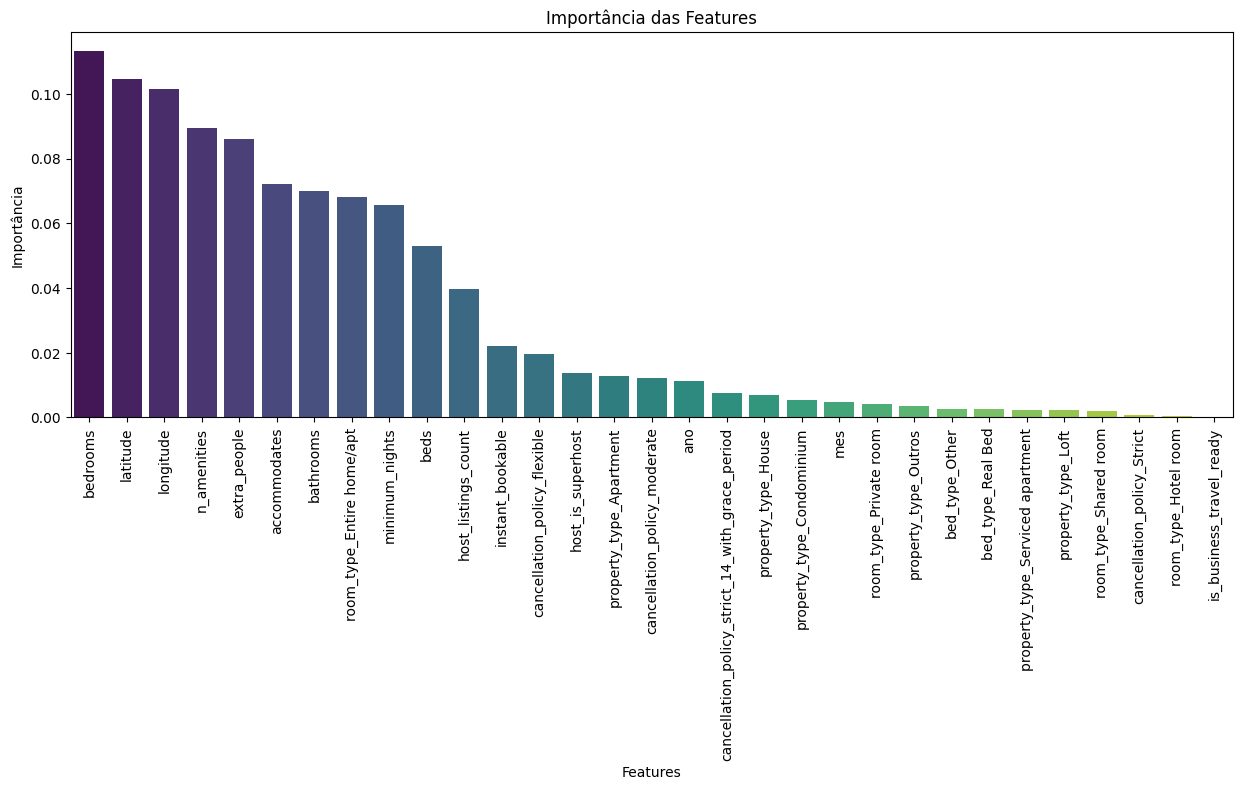

In [81]:
plt.figure(figsize=(15,5))
ax = sns.barplot(x = importancia_features.index, y = importancia_features[0], palette='viridis')
plt.title('Importância das Features')
ax.tick_params(axis = 'x', rotation = 90)
ax.set_xlabel('Features')
ax.set_ylabel('Importância')
plt.show()

Resultados iniciais da avaliação do melhor modelo:

Modelo: ExtraTrees

R²: 97.51%

RMSE: 41.82

MAE: 11.52

In [84]:
#base_airbnb_cod = base_airbnb_cod.drop('is_business_travel_ready', axis = 1)
#base_airbnb_cod = base_airbnb_cod.drop('bed_type_Real Bed', axis = 1)
#base_airbnb_cod = base_airbnb_cod.drop('bed_type_Other', axis = 1)

X = base_airbnb_cod.drop('price', axis=1)
y = base_airbnb_cod['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10)

modelo_et = ExtraTreesRegressor()

modelo_et.fit(X_train, y_train)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_prev = modelo_et.predict(X_test)
r2 = r2_score(y_test, y_prev)
mae = mean_absolute_error(y_test, y_prev)
RMSE = np.sqrt(mean_squared_error(y_test, y_prev))
print(f'''R²: {r2:.2%}
MAE: {mae:.2f}
RMSE: {RMSE:.2f}''')

R²: 97.48%
MAE: 11.56
RMSE: 42.13


In [85]:
base_airbnb_cod.columns

Index(['host_is_superhost', 'host_listings_count', 'latitude', 'longitude',
       'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'extra_people', 'minimum_nights', 'instant_bookable', 'ano', 'mes',
       'n_amenities', 'property_type_Apartment', 'property_type_Condominium',
       'property_type_House', 'property_type_Loft', 'property_type_Outros',
       'property_type_Serviced apartment', 'room_type_Entire home/apt',
       'room_type_Hotel room', 'room_type_Private room',
       'room_type_Shared room', 'cancellation_policy_Strict',
       'cancellation_policy_flexible', 'cancellation_policy_moderate',
       'cancellation_policy_strict_14_with_grace_period'],
      dtype='object')

Após a análise da importância das colunas para o modelo, eu optei por retirar 3 colunas que influenciavam pouco no aprendizado do modelo, o resultado melhorou e com isso diminuimos a complexidade do modelo, as colunas como room type e property type não foram retiradas pois algumas de suas categorias são relevantes para o modelo e não faz sentido retirarmos uma categoria e não retirar a outra, basicamente, é mais sensato manter todas as variáveis dummies neste processo.

In [86]:
importancia_features = pd.DataFrame(modelo_et.feature_importances_, X_train.columns)
importancia_features = importancia_features.sort_values(by = 0, ascending=False)
display(importancia_features)

,0
bedrooms,0.115609
latitude,0.105503
longitude,0.103524
n_amenities,0.090256
extra_people,0.086079
bathrooms,0.074882
accommodates,0.067572
room_type_Entire home/apt,0.066173
minimum_nights,0.065350
beds,0.053177


C:\Users\Arthur Lindolpho\AppData\Local\Temp\ipykernel_16724\291078423.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




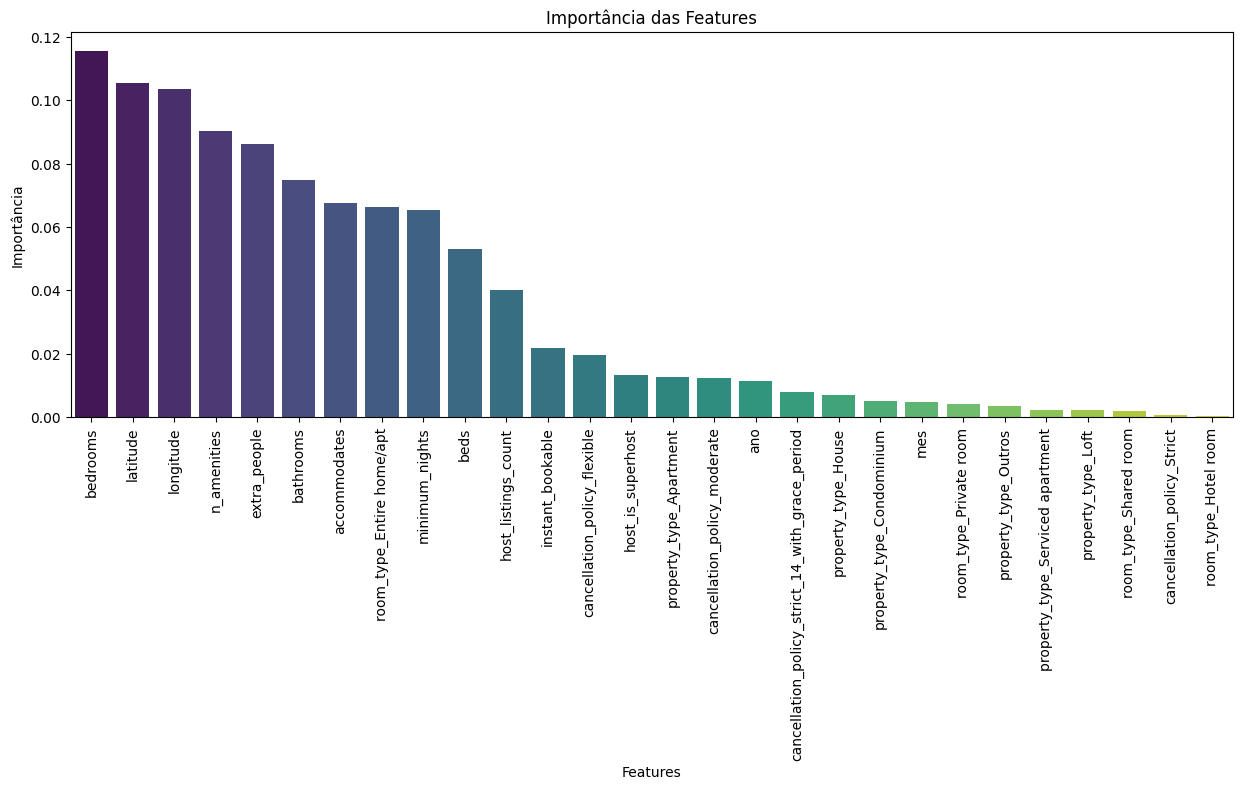

In [87]:
plt.figure(figsize=(15,5))
ax = sns.barplot(x = importancia_features.index, y = importancia_features[0], palette='viridis')
plt.title('Importância das Features')
ax.tick_params(axis = 'x', rotation = 90)
ax.set_xlabel('Features')
ax.set_ylabel('Importância')
plt.show()

## Deploy do projeto

In [ ]:
X['price'] = y
X.to_csv('dados.csv')

In [ ]:
import joblib 

joblib.dump(modelo_et, 'modelo.joblib')

['modelo.joblib']